In [1]:
# import relevant packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as ss
import seaborn as sns
from tqdm import tqdm

import torch
import torch_geometric
from torch_geometric.loader import DataLoader

# set figure parameters
sc.settings.set_figure_params(dpi=100)

# Pre-processing

/home/dchen2/anaconda3/envs/base_py39/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


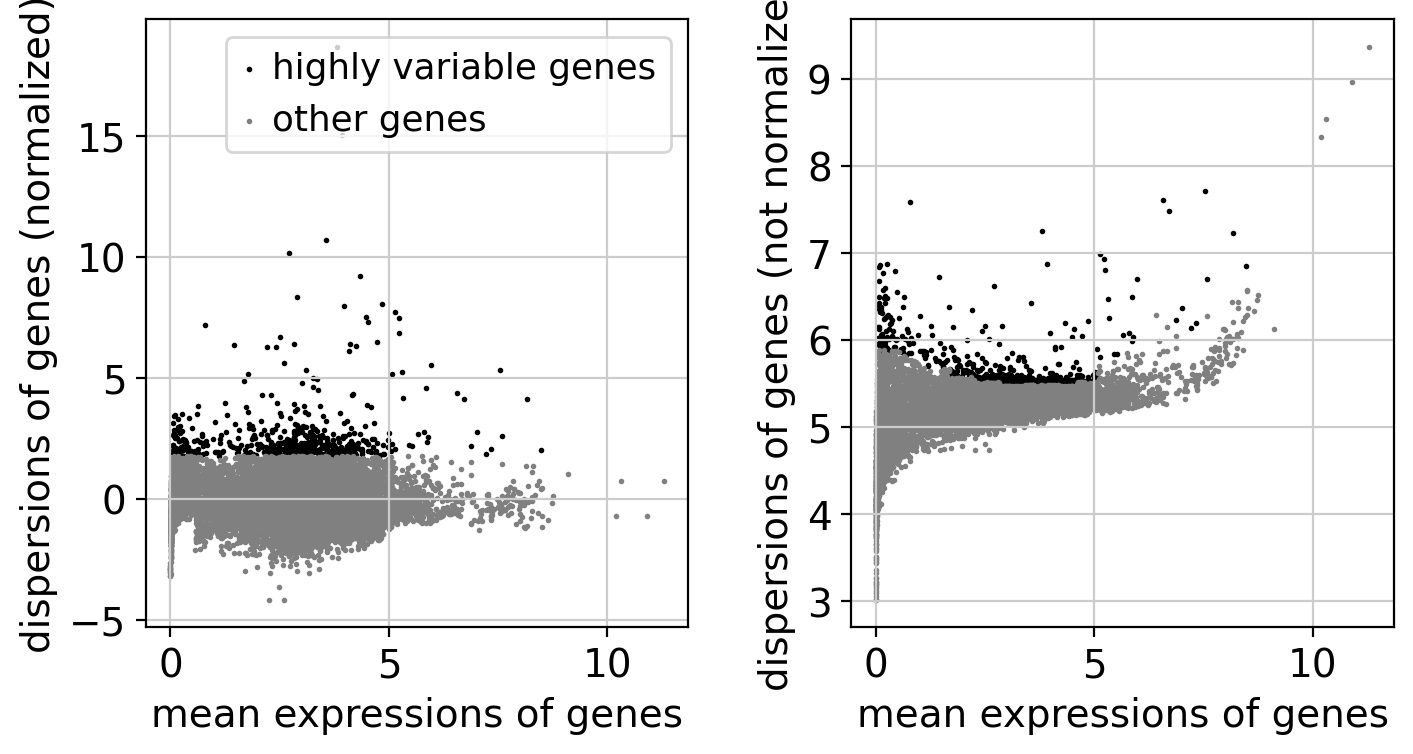

there are 500 hvgs


In [2]:
# > spleen
# read in the data
avis = sc.read_h5ad('../ccc/data/external/fetalimmune/Visium10X_data_SP.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# compute PCA for the spatial dataset using HVGs
avis.uns['log1p']['base'] = np.e
sc.pp.highly_variable_genes(avis, flavor='seurat', min_mean=0.5, max_mean=7.5, min_disp=0.5, n_top_genes=500)
sc.pl.highly_variable_genes(avis)
# define the sample indexing
sample_col = 'sample_id'
samples = avis.obs[sample_col].unique()
# report how many HVGs we're going to use
print('there are', avis.var['highly_variable'].sum(), 'hvgs')
# create a gene subset for testing
genes = avis.var_names[avis.var['highly_variable']].tolist()
avis1 = avis.copy()

In [3]:
# > lymph node
# read in the data
avis = sc.read_h5ad('../ccc/data/external/10x_multiorgans/lymphnode.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
avis2 = avis.copy()
# add necessary attributes from metadata
avis2.obs['sample_id'] = 'sample'
avis2.obsm['spatial'] = avis2.obs[['imagerow','imagecol']].values

In [4]:
from scipy.sparse import csr_matrix
# create a gene subset for testing
avis1 = avis1[:, genes].copy()
avis2 = avis2[:, genes].copy()

# convert the gene expression data to numpy and sphere normalize
# > spleen
x = torch.from_numpy(avis1.X.toarray())
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis1.X = csr_matrix(torch.div(x, norm_factor))
avis1.write_h5ad('data/preproc_spleen.h5ad')
# > lymph node
x = torch.from_numpy(avis2.X)
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis2.X = csr_matrix(torch.div(x, norm_factor))
avis2.write_h5ad('data/preproc_lymphnode.h5ad')

# Run inference module to learn intra- and inter-cellular gene-gene forces

In [5]:
# load model
from celcomen.models.celcomen import celcomen

from celcomen.training_plan.train import train

from celcomen.utils.helpers import calc_gex, get_pos, get_pos, calc_sphex, normalize_g2g

In [6]:
from torch_geometric.loader import DataLoader
import scanpy as sc
import torch
import torch_geometric
#from torch_cluster.knn import knn_graph
from sklearn.neighbors import kneighbors_graph
import numpy as np

from scipy.spatial.distance import pdist, squareform

def get_dataset_loaders(h5ad_path: str, sample_id_name: str, n_neighbors: int, device: str, verbose: bool):
    """
    Prepares and returns PyTorch Geometric DataLoader from a single-cell spatial transcriptomics dataset.

    The function reads a single-cell AnnData object from an H5AD file, normalises the data, and generates 
    graph data where nodes correspond to cells, and edges are created based on spatial proximity using 
    a k-nearest neighbours graph. The data is then loaded into a PyTorch Geometric `DataLoader`.

    Parameters
    ----------
    h5ad_path : str
        Path to the H5AD file containing the raw counts of the single-cell spatial transcriptomics data.
    sample_id_name : str
        Name of the sample ID column in `adata.obs` to separate the dataset into different samples.
    n_neighbors : int
        Number of neighbours to use for constructing the k-nearest neighbours graph for spatial information.
    verbose : bool
        If True, prints detailed information about the DataLoader during the loading process.

    Returns
    -------
    DataLoader
        A PyTorch Geometric DataLoader containing the processed graph data, with each graph representing
        a sample of cells in the dataset.

    Notes
    -----
    - The spatial positions of the cells are used to create a k-nearest neighbours graph, with edges
      connecting cells that are spatially close to each other.
    - The input features for the graph (`x`) are normalised before constructing the graph.
    - `adata.obsm["spatial"]` is used to extract the spatial coordinates of the cells.
    - The graph data is validated using PyTorch Geometric's built-in validation method.

    Examples
    --------
    >>> loader = get_dataset_loaders('data.h5ad', 'sample_id', n_neighbors=6, verbose=True)
    Step 1
    =====
    Number of graphs in the current batch: 1
    Data(x=[100, 33500], edge_index=[2, 500], pos=[100, 2], y=[1])

    Raises
    ------
    ValueError
        If there are issues with the input data during validation, e.g., if the graph is not well-formed.
    """

    adata = sc.read_h5ad(h5ad_path) 

    # sc.pp.normalize_total(adata, target_sum=1e6)
    # sc.pp.log1p(adata)

    adata_list = [  adata[adata.obs[sample_id_name]==i] for i in set(adata.obs[sample_id_name])  ]

    data_list = []
    n_neighbors = 6

    for adata in adata_list:
        pos = torch.from_numpy(adata.obsm["spatial"])
        x = torch.from_numpy(adata.X.todense())    
        # normalize x 
        norm_factor = torch.pow(x,2).sum(1).reshape(-1,1)
        x = torch.div(x, norm_factor)
        y = torch.Tensor([0])   # here we will store GT value
        # compute the edges as two cell widths apart so 30µm
        edge_index = torch.from_numpy(np.array(np.where(kneighbors_graph(adata.obsm['spatial'], n_neighbors=6, include_self=False).toarray() == 1))).to(device)
        data = torch_geometric.data.Data(x=x, pos=pos, y=y, edge_index=edge_index)
        data.validate(raise_on_error=True)    # performs basic checks on the graph
        data_list.append(data)

    loader = DataLoader( data_list, batch_size=1, shuffle=True)

    if verbose:
        for step, data in enumerate(loader):
            print(f'Step {step+1}')
            print("=====")
            print(f'Number of graphs in the current batch: {data.num_graphs}')
            print(data)
            print()

    return loader

In [7]:
# load in spleen and lymph node
n_neighbors = 6
loader1 = get_dataset_loaders('data/preproc_spleen.h5ad', 'sample_id', n_neighbors, 'cpu', True, )
loader2 = get_dataset_loaders('data/preproc_lymphnode.h5ad', 'sample_id', n_neighbors, 'cpu', True, )

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[2152, 500], edge_index=[2, 12912], y=[1], pos=[2152, 2], batch=[2152], ptr=[2])

Step 2
=====
Number of graphs in the current batch: 1
DataBatch(x=[3100, 500], edge_index=[2, 18600], y=[1], pos=[3100, 2], batch=[3100], ptr=[2])

Step 3
=====
Number of graphs in the current batch: 1
DataBatch(x=[3103, 500], edge_index=[2, 18618], y=[1], pos=[3103, 2], batch=[3103], ptr=[2])

Step 4
=====
Number of graphs in the current batch: 1
DataBatch(x=[2432, 500], edge_index=[2, 14592], y=[1], pos=[2432, 2], batch=[2432], ptr=[2])

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 500], edge_index=[2, 24210], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



### Select the hyperparameters of the model.
zmft_scalar should be the highest value in the range (0,1) such that the loss can be stably minimized. 
n_neighbors should be selected based on what disentanglement we want to achieve in the data. n_neighbors=6 targets disentanglement between intracellular and intercellular forces of short range.

In [8]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-3
zmft_scalar = 1e-1
seed = 0
epochs = 20

# instantiate models on cpu
model1 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
model2 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model1.set_g2g(torch.from_numpy(input_g2g))
model1.set_g2g_intra(torch.from_numpy(input_g2g))
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model2.set_g2g(torch.from_numpy(input_g2g))
model2.set_g2g_intra(torch.from_numpy(input_g2g))
model1.to('cpu'); model2.to('cpu')
# train the models
losses1 = train(epochs, learning_rate, model1, loader1, zmft_scalar=zmft_scalar, seed=seed, device='cpu')
losses2 = train(epochs, learning_rate, model2, loader2, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

  0%|                                                    | 0/20 [00:00<?, ?it/s]/home/dchen2/anaconda3/envs/base_py39/lib/python3.9/site-packages/torch/autograd/graph.py:744: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
100%|███████████████████████████████████████████| 20/20 [00:03<00:00,  5.47it/s]


[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Fetal immune (spleen)')]

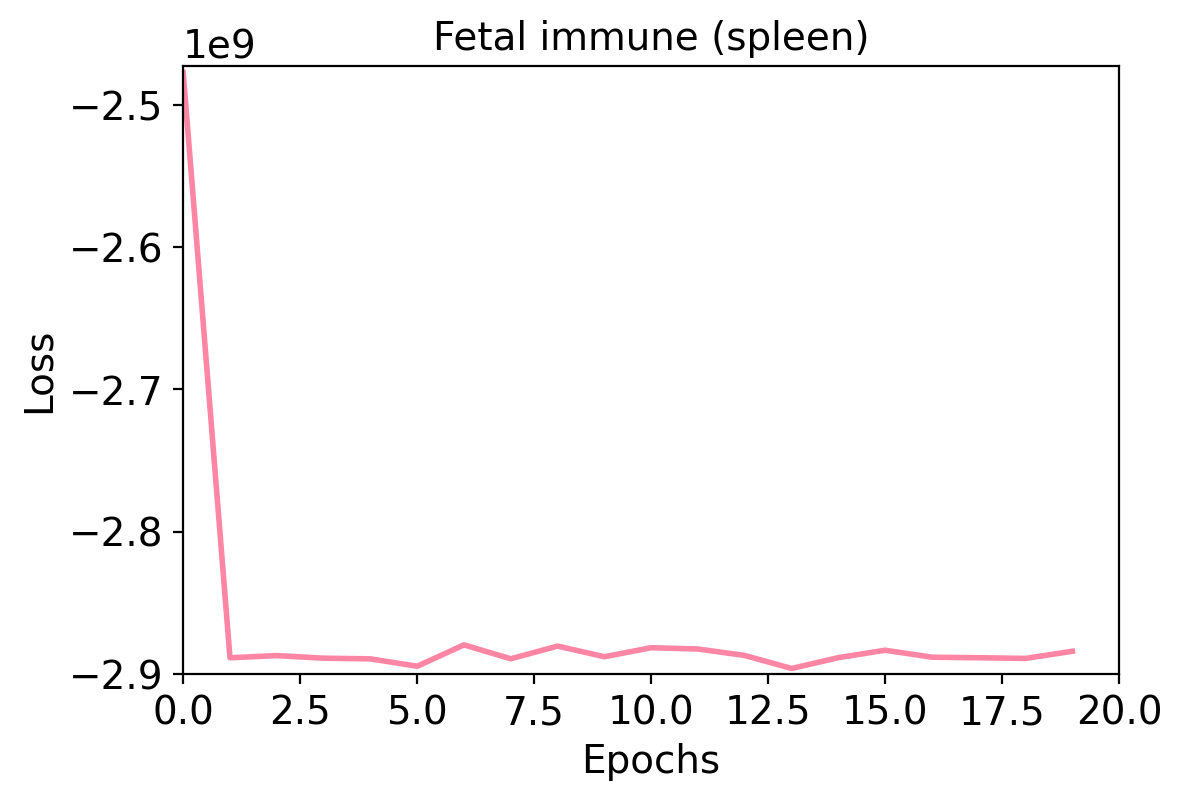

In [9]:
# create the plot for spleen
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses1, lw=2, color='#fe86a4')
ax.set_xlim(0, epochs)
vmin, vmax = min(min(losses1), 0), max(losses1)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Fetal immune (spleen)')

[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Adult immune (lymph node)')]

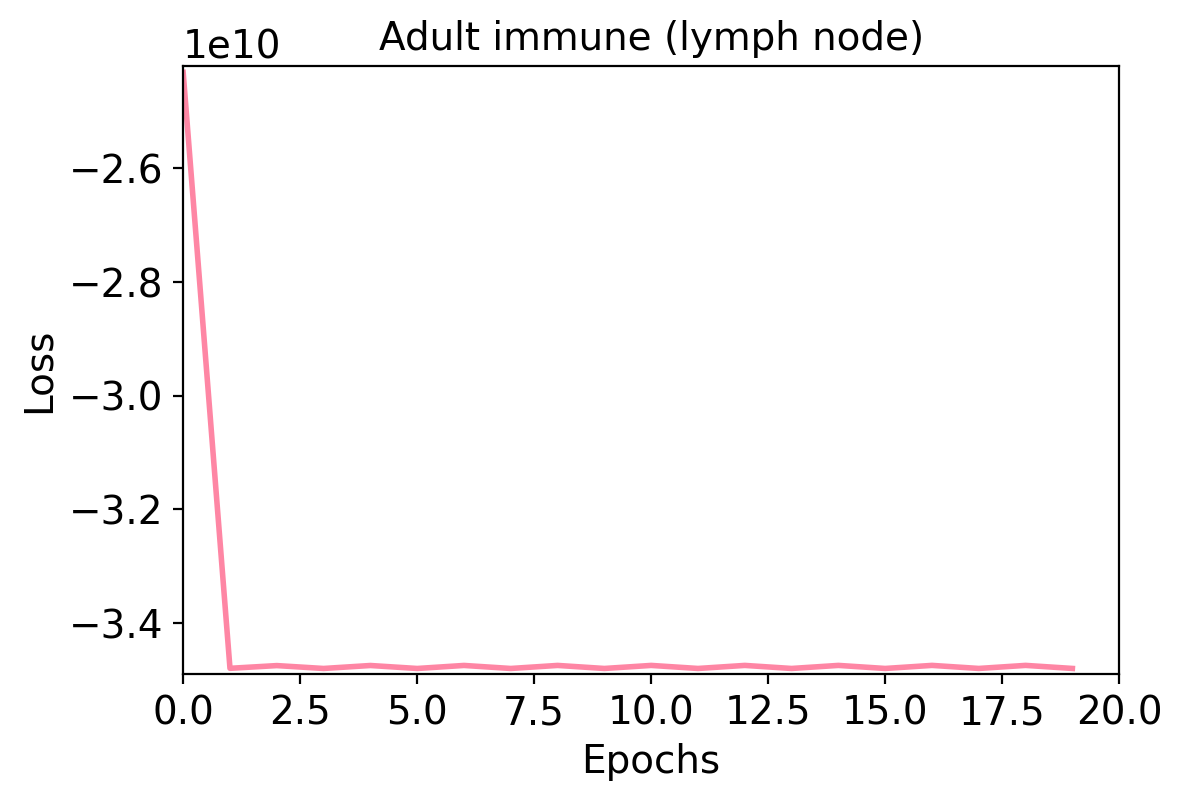

In [10]:
# create the plot for lymph node
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses2, lw=2, color='#fe86a4')
ax.set_xlim(0, epochs)
vmin, vmax = min(min(losses2), 0), max(losses2)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Adult immune (lymph node)')

The stable optimization of Celcomen indicates that zmft_scalar has been chosen appropriately.

# Confirm protein localization

In [11]:
# define the gene
secs = pd.read_table('../ccc/data/external/goids/quickgo_secreted.tsv')['SYMBOL'].unique()
sps = pd.read_table('../ccc/data/external/goids/quickgo_surfaceprotein.tsv')['SYMBOL'].unique()
nons = pd.Index(genes)[(~pd.Index(genes).isin(secs))&(~pd.Index(genes).isin(sps))]
secs = pd.Index(genes).intersection(secs)
sps = pd.Index(genes).intersection(sps)

/loc/scratch/7949135/ipykernel_1792/2855032109.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/7949135/ipykernel_1792/2855032109.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/7949135/ipykernel_1792/2855032109.py:16: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'k'}` instead.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/7949135/ipykernel_1792/2855032109.py:16: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0

8.310465962390858e-14
0.1047419759527647
1.696304917794193e-10


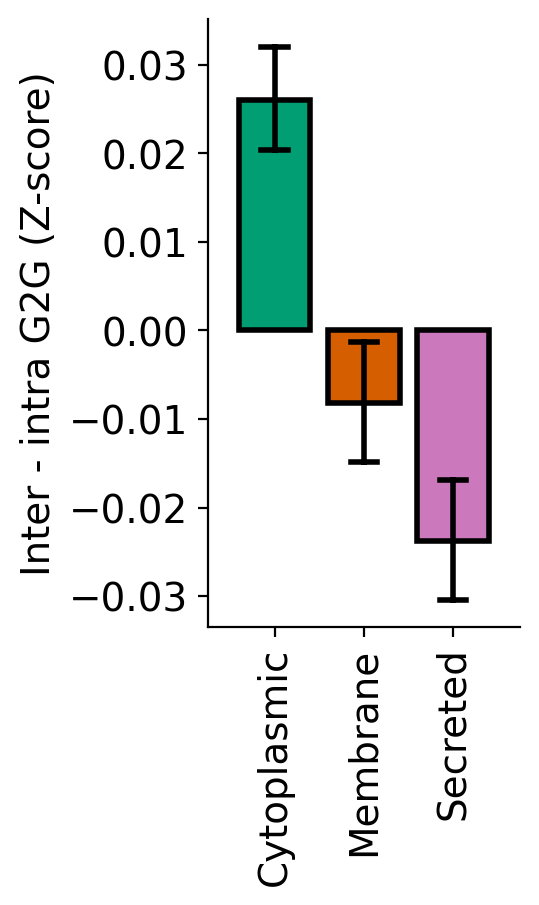

In [12]:
# derive an integrated gene-gene matrix
g2g_intracellular = pd.DataFrame(model1.lin.weight.detach().numpy(), index=genes, columns=genes)
g2g_intercellular = pd.DataFrame(model1.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
# derive the values
diffs_secs = (g2g_intercellular.loc[secs, :] - g2g_intracellular.loc[secs, :]).values.flatten()
diffs_sps = (g2g_intercellular.loc[sps, :] - g2g_intracellular.loc[sps, :]).values.flatten()
diffs_nons = (g2g_intercellular.loc[nons, :] - g2g_intracellular.loc[nons, :]).values.flatten()
# assemble them
ys = np.hstack([diffs_secs, diffs_sps, diffs_nons])
ys -= ys.mean()
ys /= ys.std()
xs = np.array(['Secreted']*len(diffs_secs)+['Membrane']*len(diffs_sps)+['Cytoplasmic']*len(diffs_nons))
# create plot
fig, ax = plt.subplots(figsize=[2, 4])
ax.grid(False)
sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
            errcolor='k', edgecolor='k', palette=['#cc78bc','#d55e00','#029e73'][::-1])
ax.set_xlim(-0.75, 2.75)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('Inter - intra G2G (Z-score)')
ax.spines[['right', 'top']].set_visible(False)
# derive pvalues
p1 = ss.mannwhitneyu(ys[xs == 'Secreted'], ys[xs == 'Membrane'])[1]
p2 = ss.mannwhitneyu(ys[xs == 'Secreted'], ys[xs == 'Cytoplasmic'])[1]
p3 = ss.mannwhitneyu(ys[xs == 'Cytoplasmic'], ys[xs == 'Membrane'])[1]
print(p1, p2, p3, sep='\n')

/loc/scratch/7949135/ipykernel_1792/264787739.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/7949135/ipykernel_1792/264787739.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/7949135/ipykernel_1792/264787739.py:16: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'k'}` instead.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/7949135/ipykernel_1792/264787739.py:16: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.

0.9038600230636842
0.002128368078899066
0.0015085304098444471


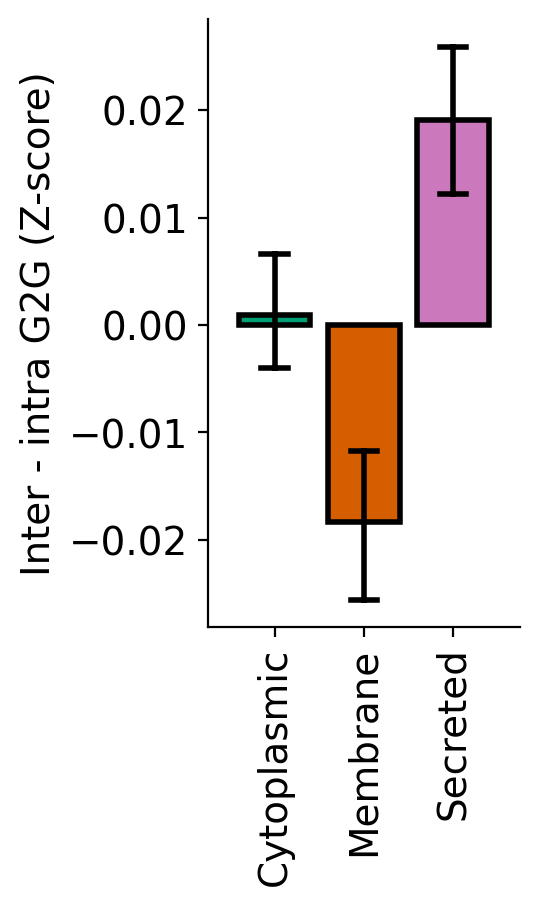

In [13]:
# derive an integrated gene-gene matrix
g2g_intracellular = pd.DataFrame(model2.lin.weight.detach().numpy(), index=genes, columns=genes)
g2g_intercellular = pd.DataFrame(model2.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
# derive the values
diffs_secs = (g2g_intercellular.loc[secs, :] - g2g_intracellular.loc[secs, :]).values.flatten()
diffs_sps = (g2g_intercellular.loc[sps, :] - g2g_intracellular.loc[sps, :]).values.flatten()
diffs_nons = (g2g_intercellular.loc[nons, :] - g2g_intracellular.loc[nons, :]).values.flatten()
# assemble them
ys = np.hstack([diffs_secs, diffs_sps, diffs_nons])
ys -= ys.mean()
ys /= ys.std()
xs = np.array(['Secreted']*len(diffs_secs)+['Membrane']*len(diffs_sps)+['Cytoplasmic']*len(diffs_nons))
# create plot
fig, ax = plt.subplots(figsize=[2, 4])
ax.grid(False)
sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
            errcolor='k', edgecolor='k', palette=['#cc78bc','#d55e00','#029e73'][::-1])
ax.set_xlim(-0.75, 2.75)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('Inter - intra G2G (Z-score)')
ax.spines[['right', 'top']].set_visible(False)
# derive pvalues
p1 = ss.mannwhitneyu(ys[xs == 'Secreted'], ys[xs == 'Membrane'])[1]
p2 = ss.mannwhitneyu(ys[xs == 'Secreted'], ys[xs == 'Cytoplasmic'])[1]
p3 = ss.mannwhitneyu(ys[xs == 'Cytoplasmic'], ys[xs == 'Membrane'])[1]
print(p1, p2, p3, sep='\n')

# Interpret gene interaction matrices (intracellular)

In [51]:
# compare intracellular
g2g_intra1 = pd.DataFrame(model1.lin.weight.detach().numpy(), index=genes, columns=genes)
g2g_intra2 = pd.DataFrame(model2.lin.weight.detach().numpy(), index=genes, columns=genes)

In [52]:
from scipy.cluster.hierarchy import linkage, fcluster
# compute fetal - adult
g2g_diff = g2g_intra1 - g2g_intra2
# compute linkages
Z = linkage(g2g_diff, method='ward')

In [53]:
from sklearn.metrics import silhouette_score
# choose an optimal clustering
df_scores = pd.DataFrame(columns=['t','score','min_size','max_size','avg_size','median_size'])
for t in range(3, 20+1):
    clusters = fcluster(Z, criterion='maxclust', t=t)
    score = silhouette_score(g2g_diff, clusters)
    counts = pd.Series(clusters).value_counts()
    df_scores.loc[df_scores.shape[0]] = t, score, min(counts), max(counts), np.mean(counts), np.median(counts)

Text(0, 0.5, 'Min cluster size (dashed black)')

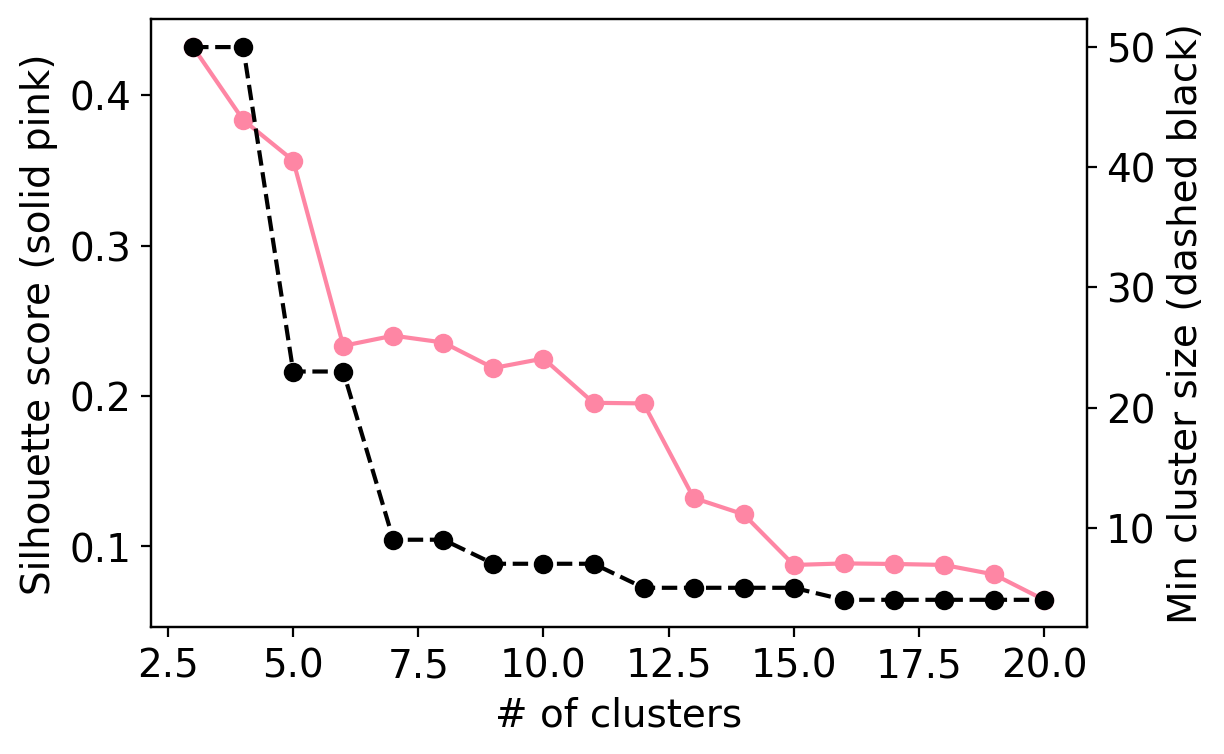

In [54]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['min_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Min cluster size (dashed black)')

Text(0, 0.5, 'Max cluster size (dashed black)')

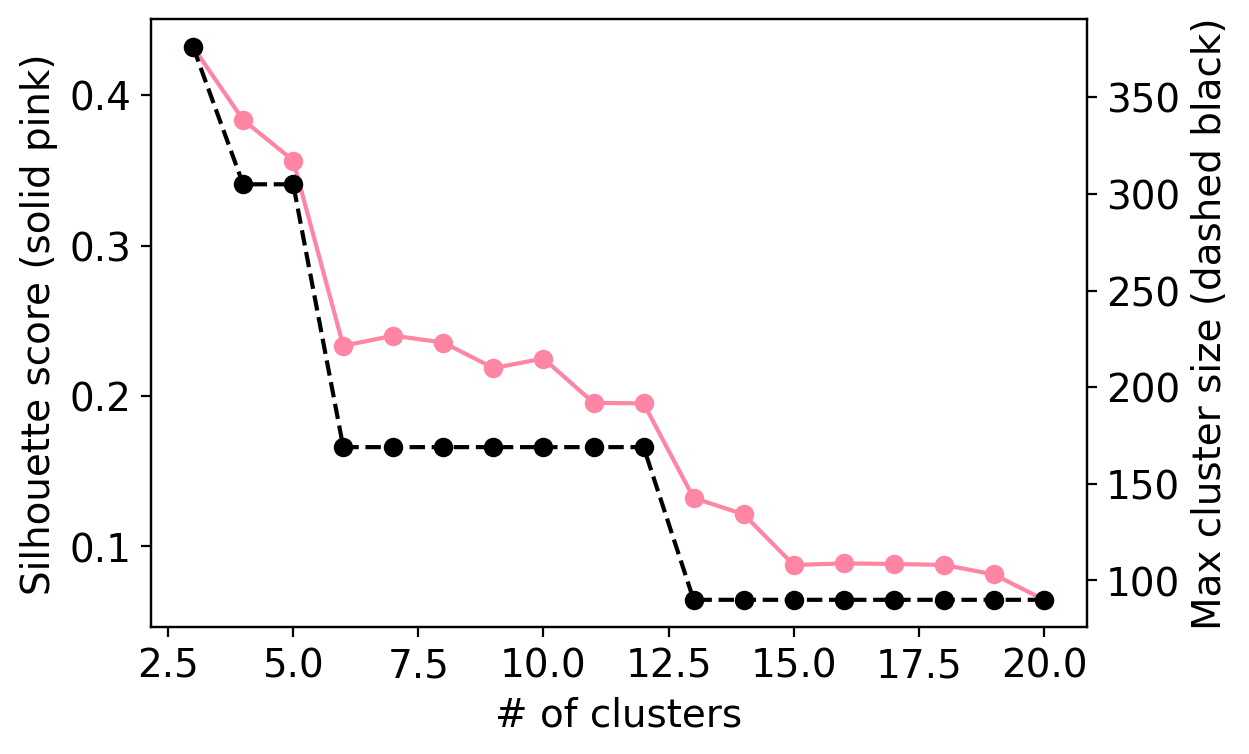

In [55]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['max_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Max cluster size (dashed black)')

Text(0, 0.5, 'Mean cluster size (dashed black)')

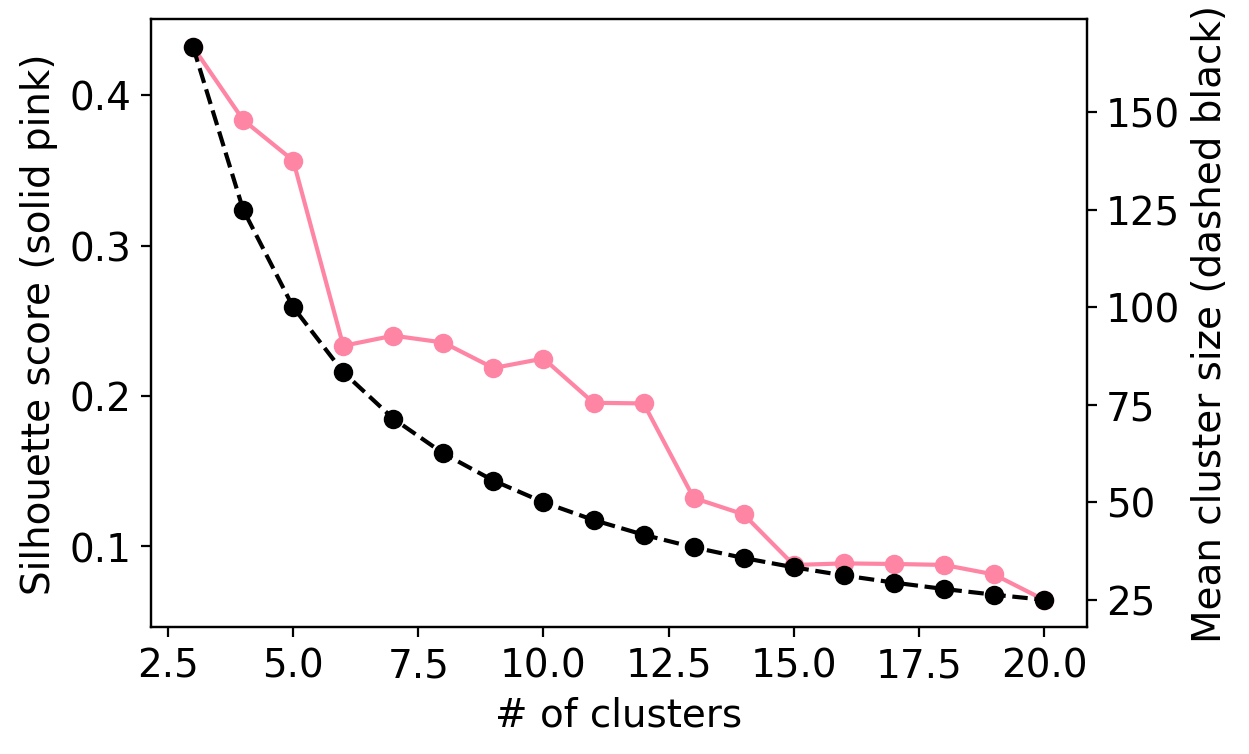

In [56]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['avg_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Mean cluster size (dashed black)')

Text(0, 0.5, 'Median cluster size (dashed black)')

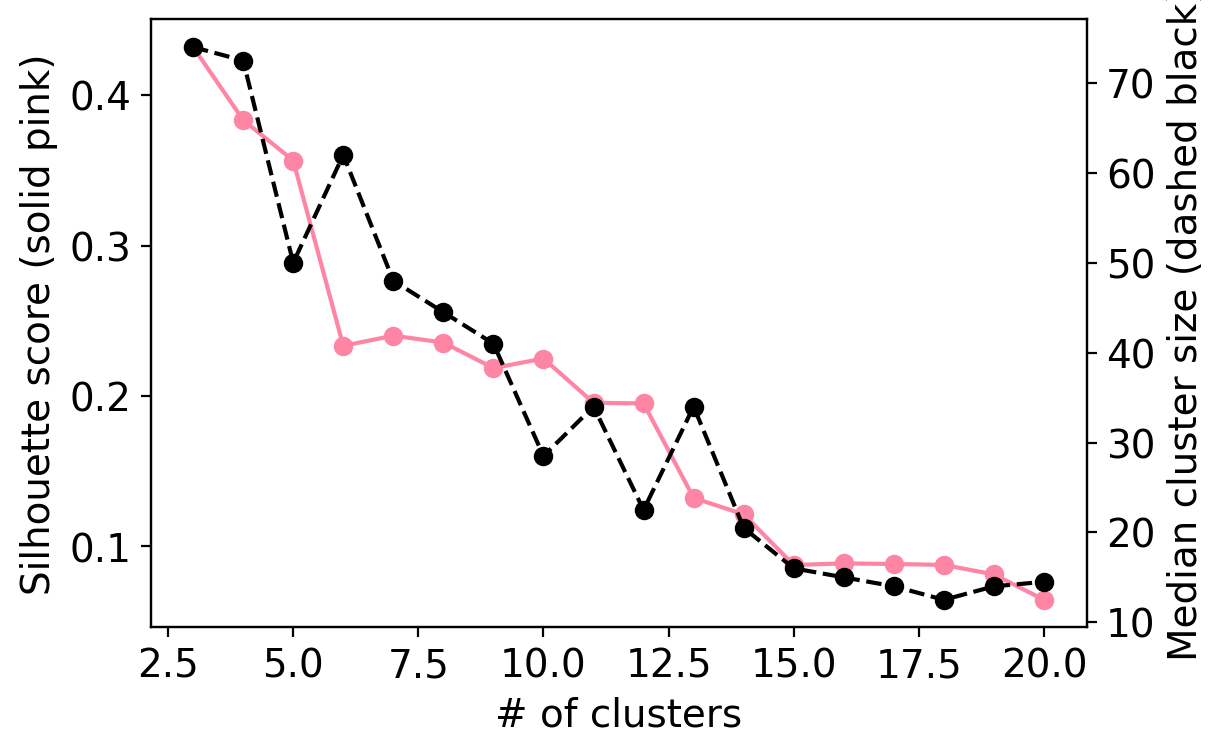

In [57]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['median_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Median cluster size (dashed black)')

[Text(0.5, 0, 'Interaction difference cluster')]

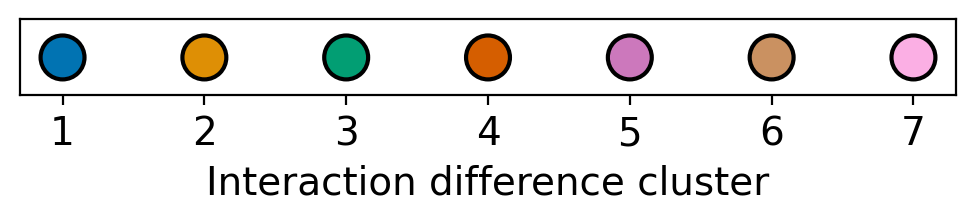

In [58]:
# create the colors and a legend
t = 7
clusters = pd.Series(fcluster(Z, criterion='maxclust', t=t), index=genes)
palette = sns.color_palette('colorblind', t).as_hex()
c2c = {idx+1:c for idx, c in enumerate(palette)}
# plot the legend
fig, ax = plt.subplots(figsize=[6, 0.5]); ax.grid(False)
ax.scatter(range(1, t+1), [0]*t, color=palette, s=2.5e2, edgecolor='k', linewidth=1.5)
ax.set_yticks([]); ax.set_xticks(range(1, t+1)); ax.set_xticklabels(range(1, t+1))
ax.set(xlabel='Interaction difference cluster')

[]

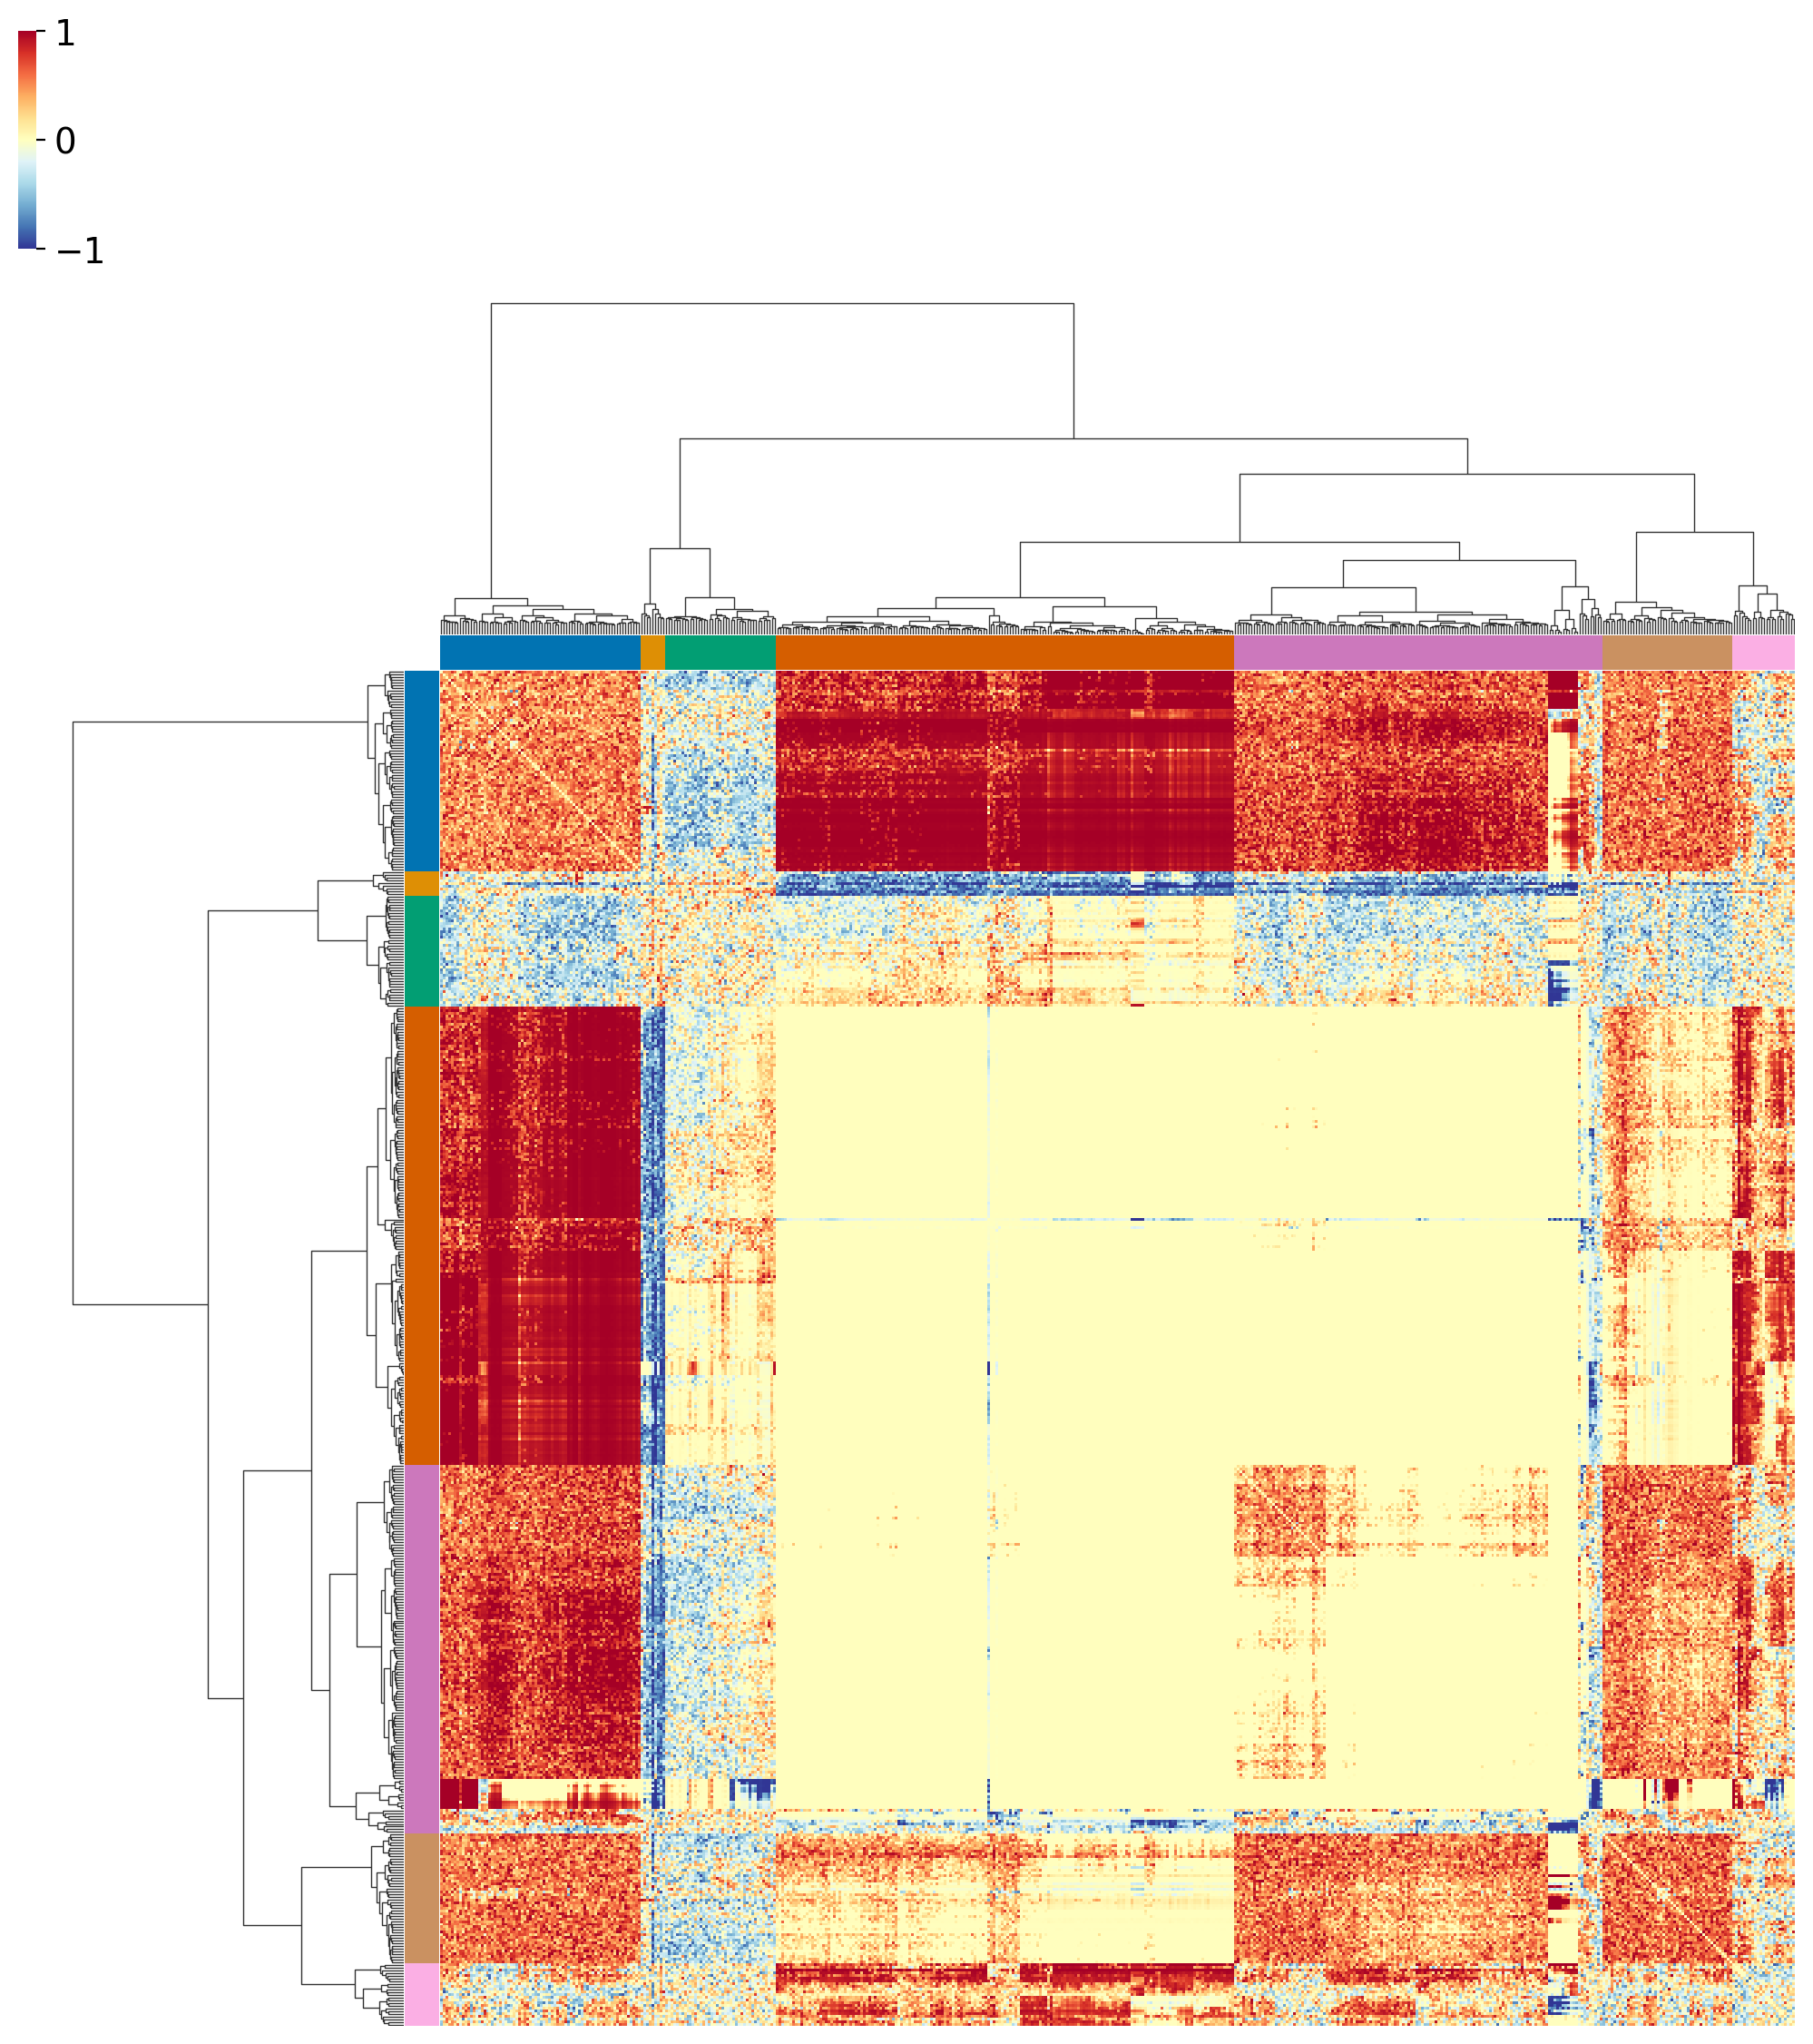

In [59]:
# show the differences
colors = clusters.map(c2c)
g = sns.clustermap(g2g_diff, vmin=-1, vmax=1, cmap='RdYlBu_r',
                   method='ward', cbar_pos=(0, 1, .01, .12), 
                   row_linkage=Z, col_linkage=Z, colors_ratio=(.02),
                   row_colors=colors, col_colors=colors,
                   xticklabels=0, yticklabels=0)
g.ax_heatmap.grid(False); g.ax_cbar.grid(False)
g.ax_col_colors.grid(False); g.ax_col_colors.set_yticks([])
g.ax_row_colors.grid(False); g.ax_row_colors.set_xticks([])

In [60]:
# assemble the non-symmetric non-identical interactions
datas = []
for cluster in clusters.unique():
    idxs = clusters.index[clusters == cluster]
    # get non-identical
    values = g2g_diff.loc[idxs, idxs].values
    flat = []
    for idx in range(values.shape[1]-1):
        flat.extend(values[idx, idx+1:].tolist())
    data = pd.DataFrame(flat, columns=['value'])
    data['cluster'] = cluster
    datas.append(data)
data = pd.concat(datas, axis=0)

/loc/scratch/7949135/ipykernel_1792/769348346.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
/loc/scratch/7949135/ipykernel_1792/769348346.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
/loc/scratch/7949135/ipykernel_1792/769348346.py:3: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'k'}` instead.

  sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
/loc/scratch/7949135/ipykernel_1792/769348346.py:3: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass

KW p=0.000e+00


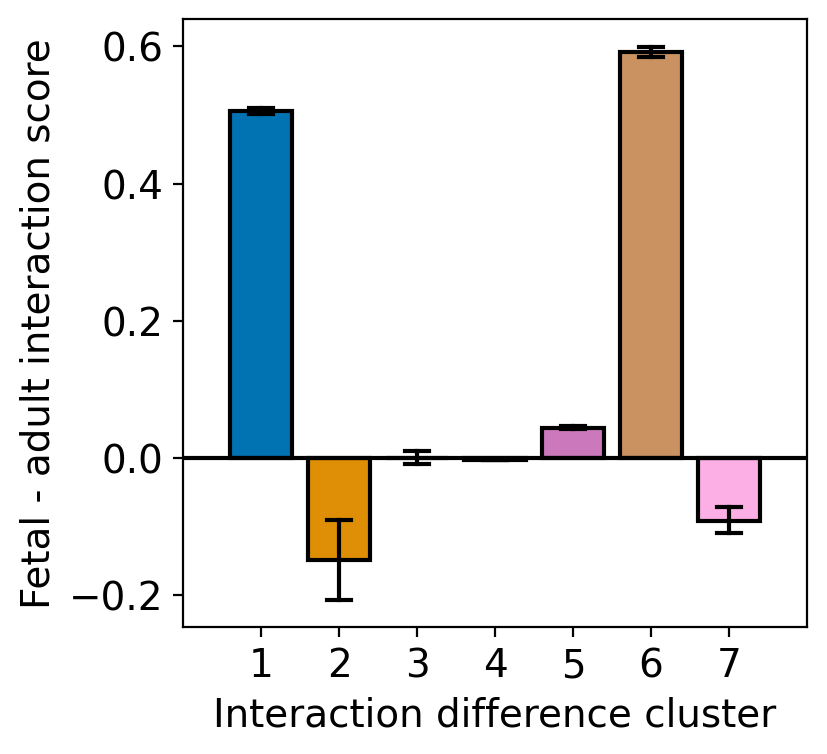

In [61]:
# identify differences with KW
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
            ci=68, errwidth=1.5, capsize=0.3, errcolor='k', saturation=1)
ax.plot([-1, t], [0]*2, color='k'); ax.set_xlim(-1, t)
ax.set(xlabel='Interaction difference cluster', ylabel='Fetal - adult interaction score')
print('KW p=%.3e' % ss.kruskal(*[data['value'] for data in datas])[1])

In [63]:
# investigate 1, 2, 4, 6
# for x in clusters.index[clusters == 1]:
#     print(x)

/loc/scratch/7949135/ipykernel_26284/3827169641.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Reds')


Text(0.5, 1.0, 'Interaction difference cluster 1')

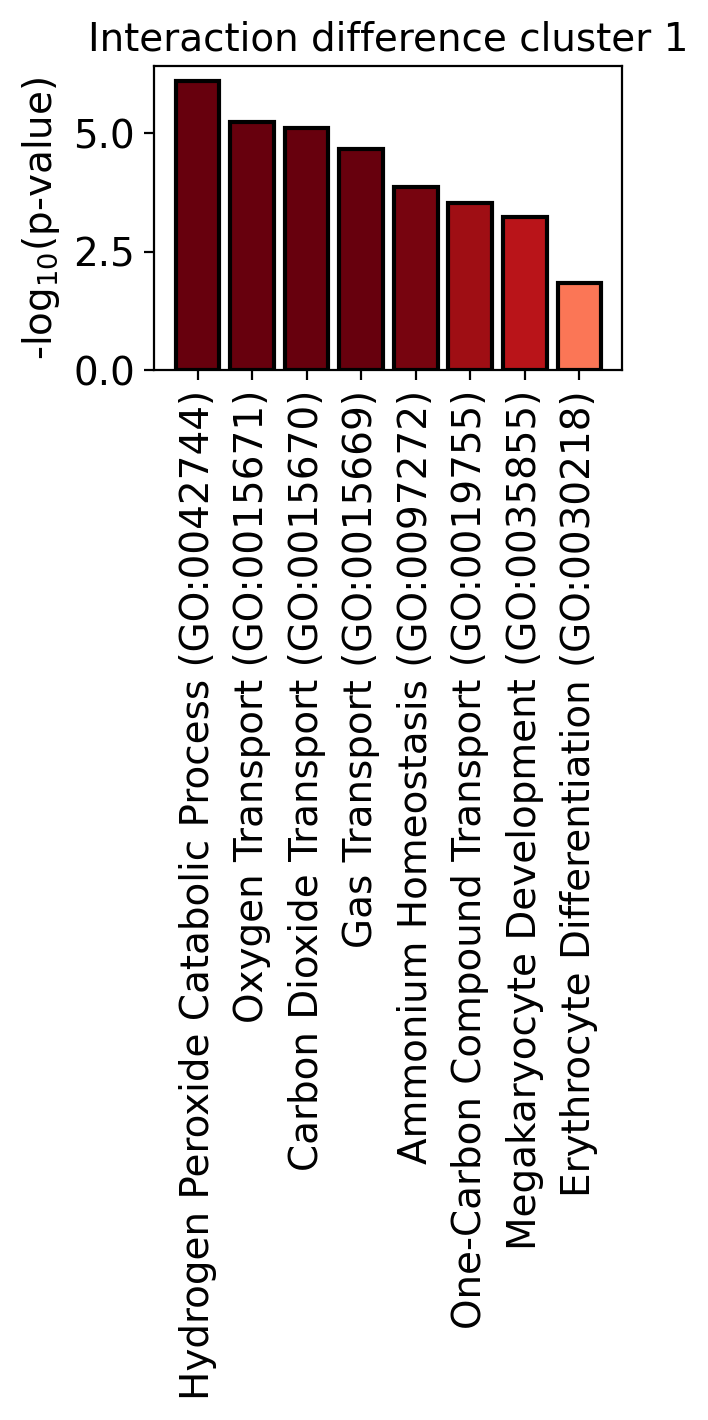

In [3]:
from matplotlib.cm import get_cmap
from matplotlib.colors import to_hex
# read in the enrichments (for non-enrichments)
pathways = '''Hydrogen Peroxide Catabolic Process (GO:0042744)
Oxygen Transport (GO:0015671)
Carbon Dioxide Transport (GO:0015670)
Gas Transport (GO:0015669)
Ammonium Homeostasis (GO:0097272)
One-Carbon Compound Transport (GO:0019755)
Megakaryocyte Development (GO:0035855)
Erythrocyte Differentiation (GO:0030218)'''.split('\n')
pvals = [float(x) for x in '''8.00E-07
5.73E-06
7.85E-06
2.14E-05
1.34E-04
2.92E-04
5.96E-04
0.014196061'''.split('\n')]

# retrieve the colors
ys = -np.log10(pvals)
colors = [y/4 for y in ys]
cmap = get_cmap('Reds')
colors = [to_hex(cmap(c)) for c in colors]
# plot the colored bars
fig, ax = plt.subplots(figsize=[3, 2]); ax.grid(False)
ax.bar(pathways, ys, edgecolor='k', linewidth=1.5, color=colors)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('-log$_{10}$(p-value)')
ax.set_title('Interaction difference cluster 1')

/loc/scratch/7949135/ipykernel_26284/2653505070.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Reds')


Text(0.5, 1.0, 'Interaction difference cluster 2')

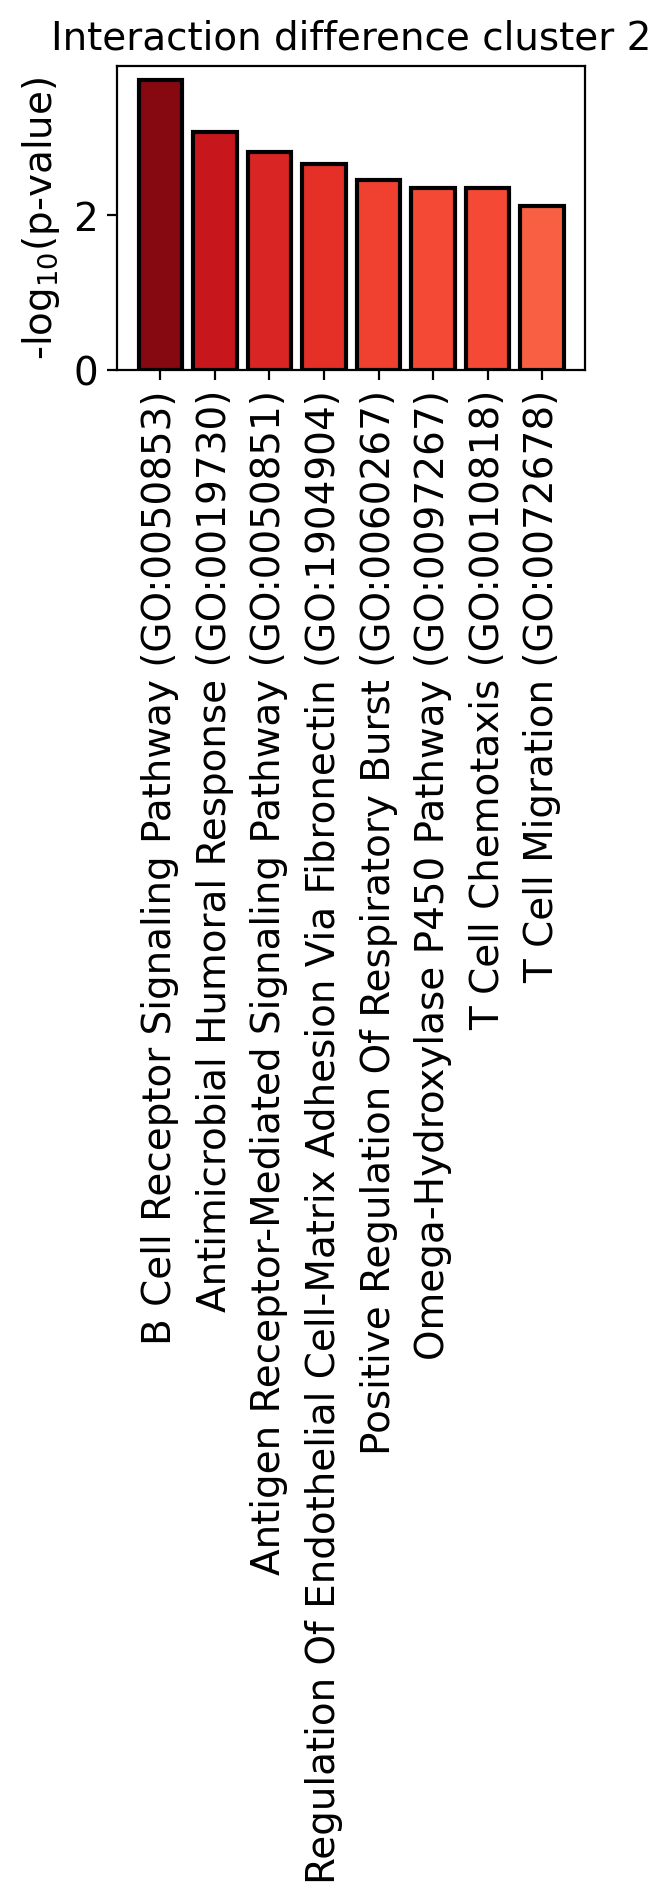

In [4]:
# read in the enrichments (for non-enrichments)
pathways = '''B Cell Receptor Signaling Pathway (GO:0050853)
Antimicrobial Humoral Response (GO:0019730)
Antigen Receptor-Mediated Signaling Pathway (GO:0050851)
Regulation Of Endothelial Cell-Matrix Adhesion Via Fibronectin (GO:1904904)
Positive Regulation Of Respiratory Burst (GO:0060267)
Omega-Hydroxylase P450 Pathway (GO:0097267)
T Cell Chemotaxis (GO:0010818)
T Cell Migration (GO:0072678)'''.split('\n')
pvals = [float(x) for x in '''1.84E-04
8.71E-04
0.00155534
0.002248161
0.003594909
0.004491844
0.004491844
0.007625474'''.split('\n')]

# retrieve the colors
ys = -np.log10(pvals)
colors = [y/4 for y in ys]
cmap = get_cmap('Reds')
colors = [to_hex(cmap(c)) for c in colors]
# plot the colored bars
fig, ax = plt.subplots(figsize=[3, 2]); ax.grid(False)
ax.bar(pathways, ys, edgecolor='k', linewidth=1.5, color=colors)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('-log$_{10}$(p-value)')
ax.set_title('Interaction difference cluster 2')

/loc/scratch/7949135/ipykernel_26284/1164060606.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Reds')


Text(0.5, 1.0, 'Interaction difference cluster 4')

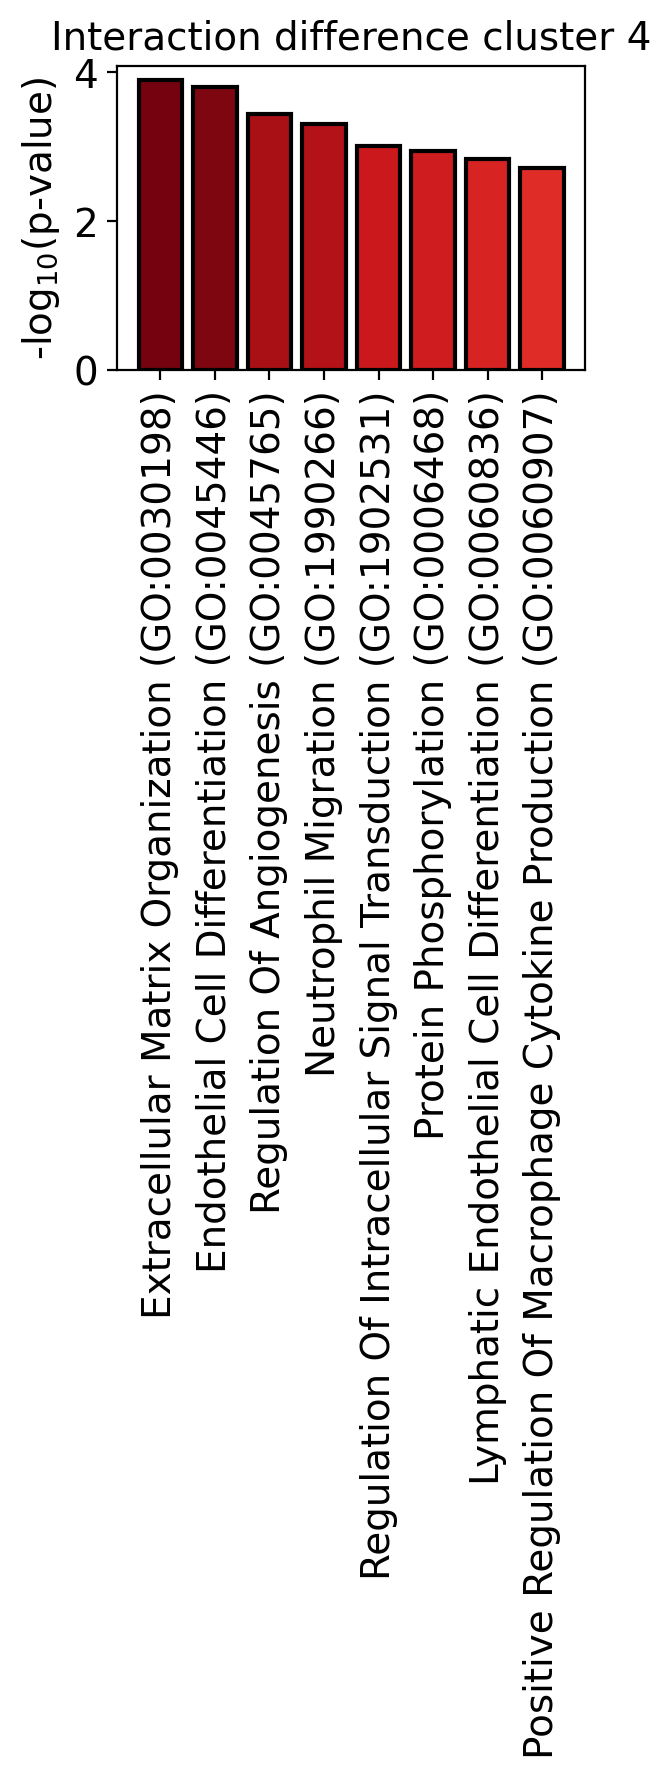

In [5]:
# read in the enrichments (for non-enrichments)
pathways = '''Extracellular Matrix Organization (GO:0030198)
Endothelial Cell Differentiation (GO:0045446)
Regulation Of Angiogenesis (GO:0045765)
Neutrophil Migration (GO:1990266)
Regulation Of Intracellular Signal Transduction (GO:1902531)
Protein Phosphorylation (GO:0006468)
Lymphatic Endothelial Cell Differentiation (GO:0060836)
Positive Regulation Of Macrophage Cytokine Production (GO:0060907)'''.split('\n')
pvals = [float(x) for x in '''1.29E-04
1.59E-04
3.63E-04
4.91E-04
9.79E-04
0.0011472
0.001449643
0.001922136'''.split('\n')]

# retrieve the colors
ys = -np.log10(pvals)
colors = [y/4 for y in ys]
cmap = get_cmap('Reds')
colors = [to_hex(cmap(c)) for c in colors]
# plot the colored bars
fig, ax = plt.subplots(figsize=[3, 2]); ax.grid(False)
ax.bar(pathways, ys, edgecolor='k', linewidth=1.5, color=colors)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('-log$_{10}$(p-value)')
ax.set_title('Interaction difference cluster 4')

/loc/scratch/7949135/ipykernel_26284/1306964430.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Reds')


Text(0.5, 1.0, 'Interaction difference cluster 6')

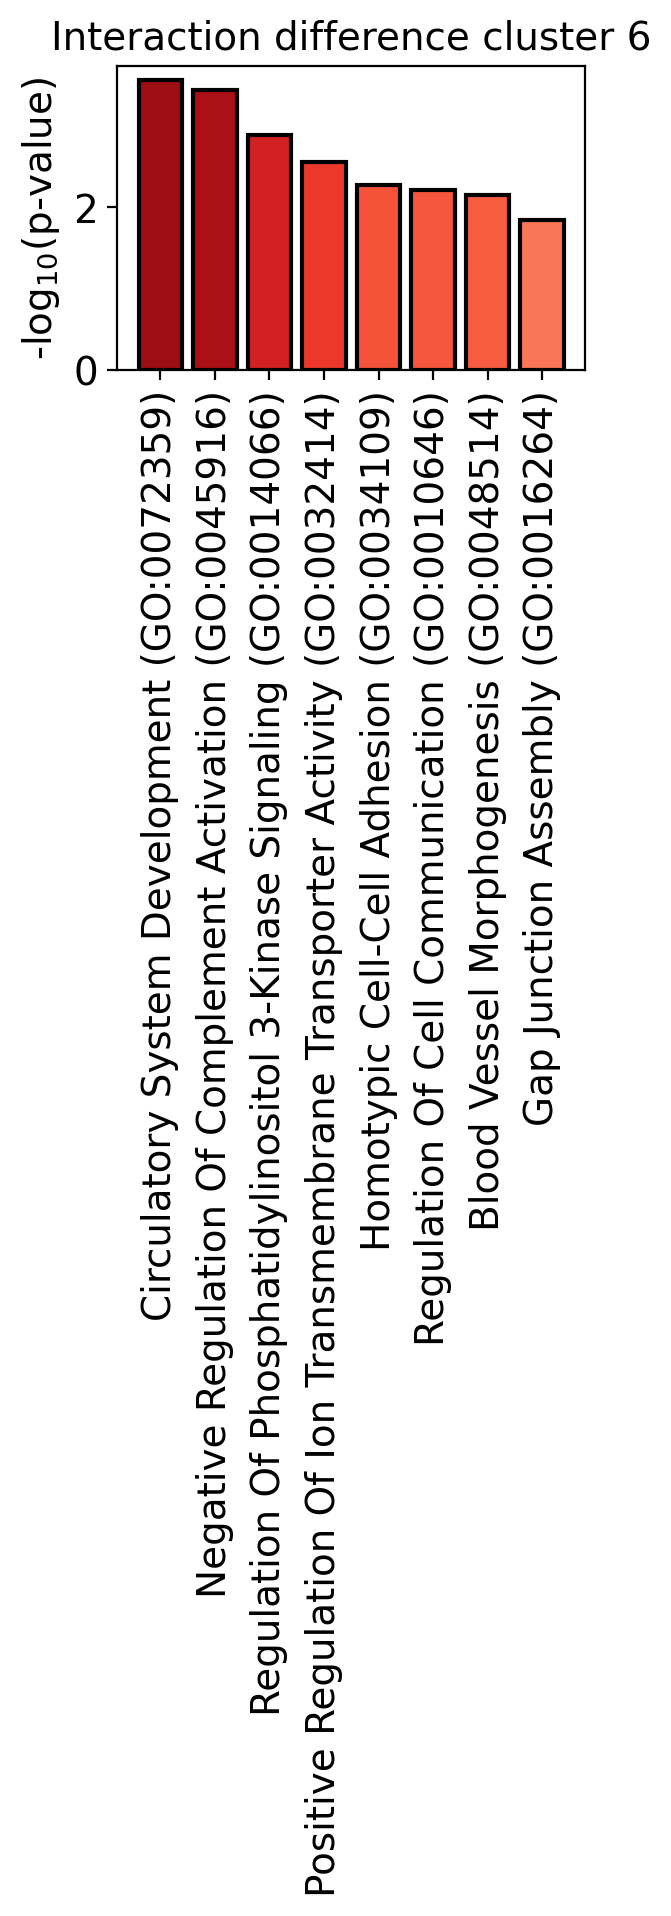

In [7]:
# read in the enrichments (for non-enrichments)
pathways = '''Circulatory System Development (GO:0072359)
Negative Regulation Of Complement Activation (GO:0045916)
Regulation Of Phosphatidylinositol 3-Kinase Signaling (GO:0014066)
Positive Regulation Of Ion Transmembrane Transporter Activity (GO:0032414)
Homotypic Cell-Cell Adhesion (GO:0034109)
Regulation Of Cell Communication (GO:0010646)
Blood Vessel Morphogenesis (GO:0048514)
Gap Junction Assembly (GO:0016264)'''.split('\n')
pvals = [float(x) for x in '''2.82E-04
3.67E-04
0.00131646
0.002839972
0.005457674
0.006172903
0.007189288
0.014315529'''.split('\n')][:8]

# retrieve the colors
ys = -np.log10(pvals)
colors = [y/4 for y in ys]
cmap = get_cmap('Reds')
colors = [to_hex(cmap(c)) for c in colors]
# plot the colored bars
fig, ax = plt.subplots(figsize=[3, 2]); ax.grid(False)
ax.bar(pathways, ys, edgecolor='k', linewidth=1.5, color=colors)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('-log$_{10}$(p-value)')
ax.set_title('Interaction difference cluster 6')

# Interpret gene interaction matrices (intercellular)

In [66]:
# compare intracellular
g2g_inter1 = pd.DataFrame(model1.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
g2g_inter2 = pd.DataFrame(model2.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)

In [67]:
from scipy.cluster.hierarchy import linkage, fcluster
# compute fetal - adult
g2g_diff = g2g_inter1 - g2g_inter2
# compute linkages
Z = linkage(g2g_diff, method='ward')

In [68]:
from sklearn.metrics import silhouette_score
# choose an optimal clustering
df_scores = pd.DataFrame(columns=['t','score','min_size','max_size','avg_size','median_size'])
for t in range(3, 20+1):
    clusters = fcluster(Z, criterion='maxclust', t=t)
    score = silhouette_score(g2g_diff, clusters)
    counts = pd.Series(clusters).value_counts()
    df_scores.loc[df_scores.shape[0]] = t, score, min(counts), max(counts), np.mean(counts), np.median(counts)

Text(0, 0.5, 'Min cluster size (dashed black)')

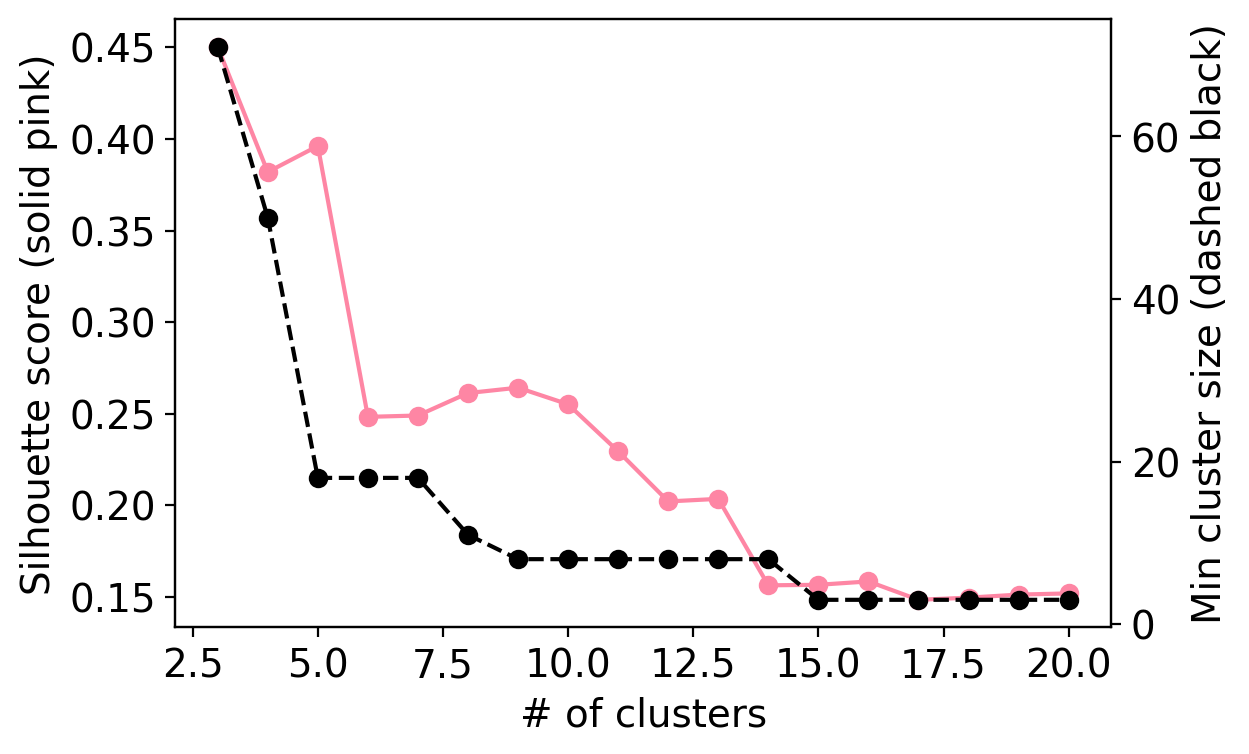

In [69]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['min_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Min cluster size (dashed black)')

Text(0, 0.5, 'Max cluster size (dashed black)')

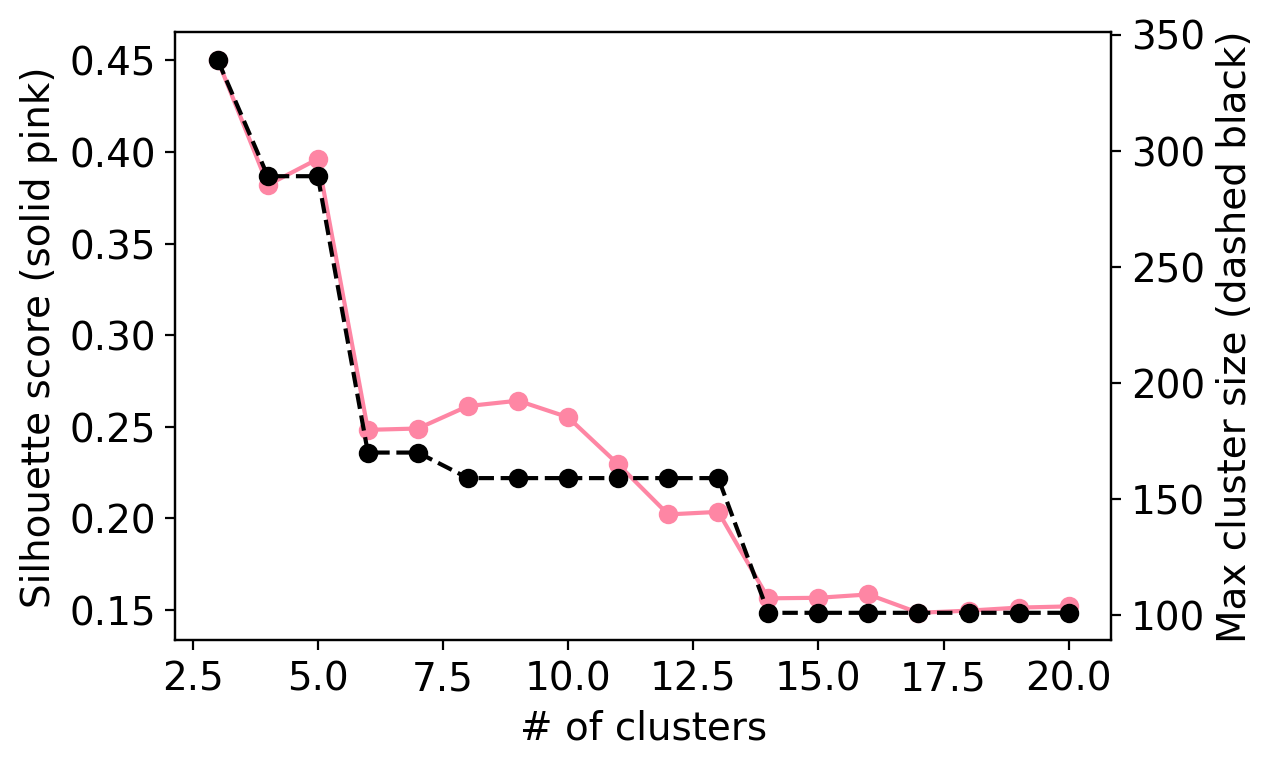

In [70]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['max_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Max cluster size (dashed black)')

Text(0, 0.5, 'Mean cluster size (dashed black)')

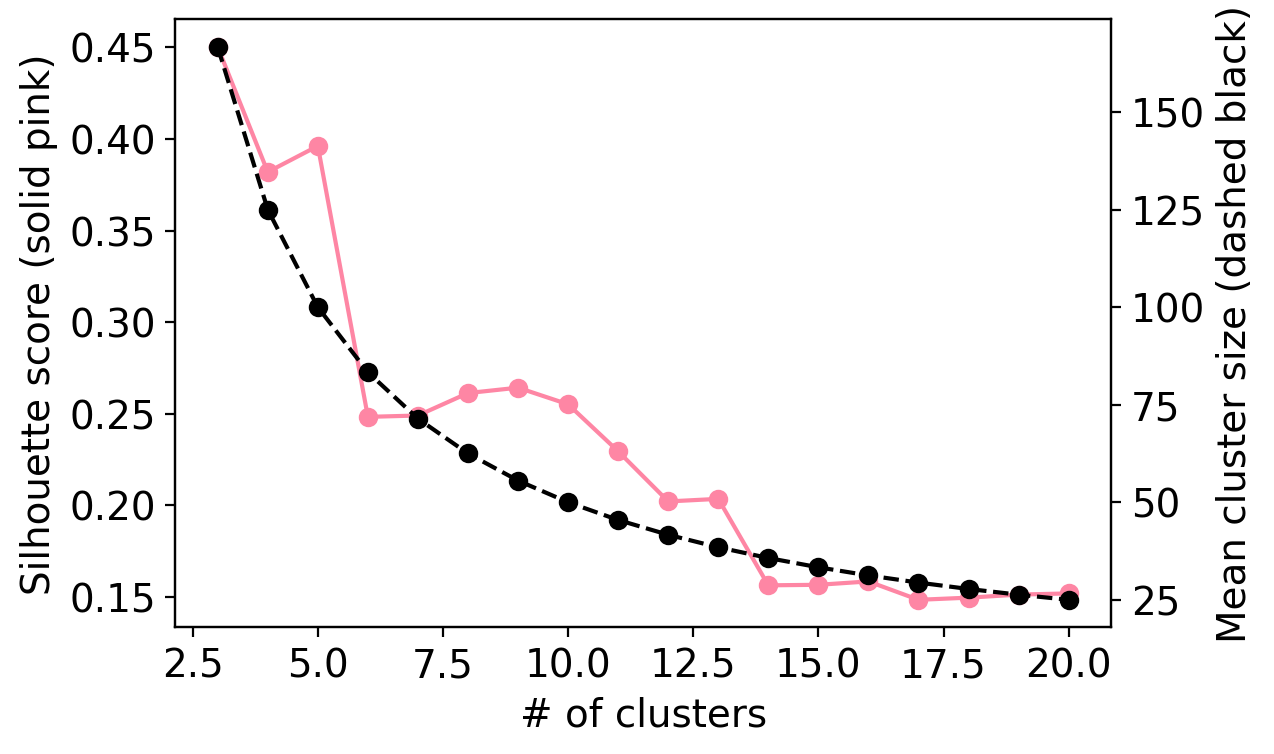

In [71]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['avg_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Mean cluster size (dashed black)')

Text(0, 0.5, 'Median cluster size (dashed black)')

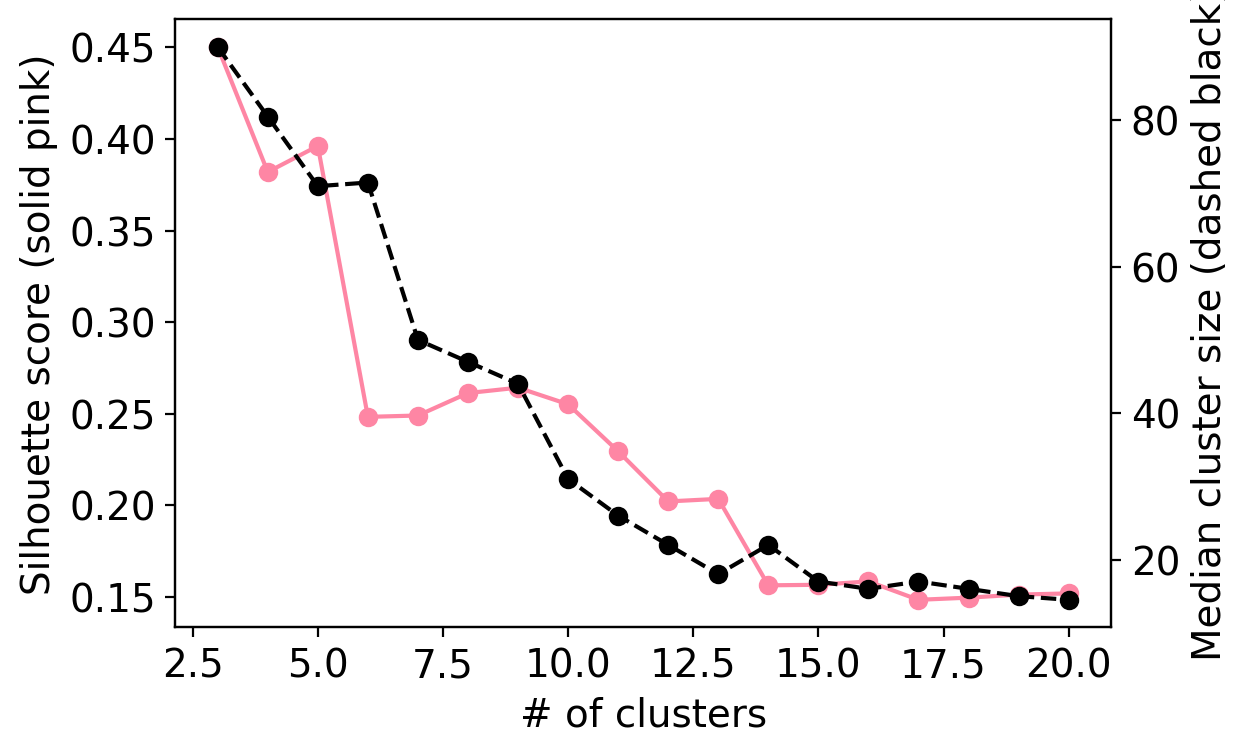

In [72]:
# plot the silhouette score
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
ax.plot(df_scores['t'], df_scores['score'], color='#fe86a4', marker='o')
ax.set(xlabel='# of clusters', ylabel='Silhouette score (solid pink)')
# plot on the average cluster size
ax_t = ax.twinx(); ax_t.grid(False)
ax_t.plot(df_scores['t'], df_scores['median_size'],marker='o', linestyle='--', color='k')
ax_t.set_ylabel('Median cluster size (dashed black)')

[Text(0.5, 0, 'Interaction difference cluster')]

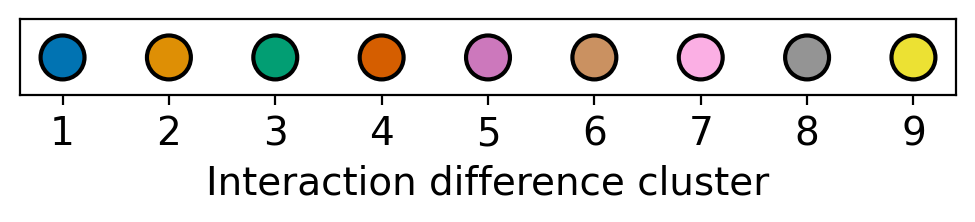

In [73]:
# create the colors and a legend
t = 9
clusters = pd.Series(fcluster(Z, criterion='maxclust', t=t), index=genes)
palette = sns.color_palette('colorblind', t).as_hex()
c2c = {idx+1:c for idx, c in enumerate(palette)}
# plot the legend
fig, ax = plt.subplots(figsize=[6, 0.5]); ax.grid(False)
ax.scatter(range(1, t+1), [0]*t, color=palette, s=2.5e2, edgecolor='k', linewidth=1.5)
ax.set_yticks([]); ax.set_xticks(range(1, t+1)); ax.set_xticklabels(range(1, t+1))
ax.set(xlabel='Interaction difference cluster')

[]

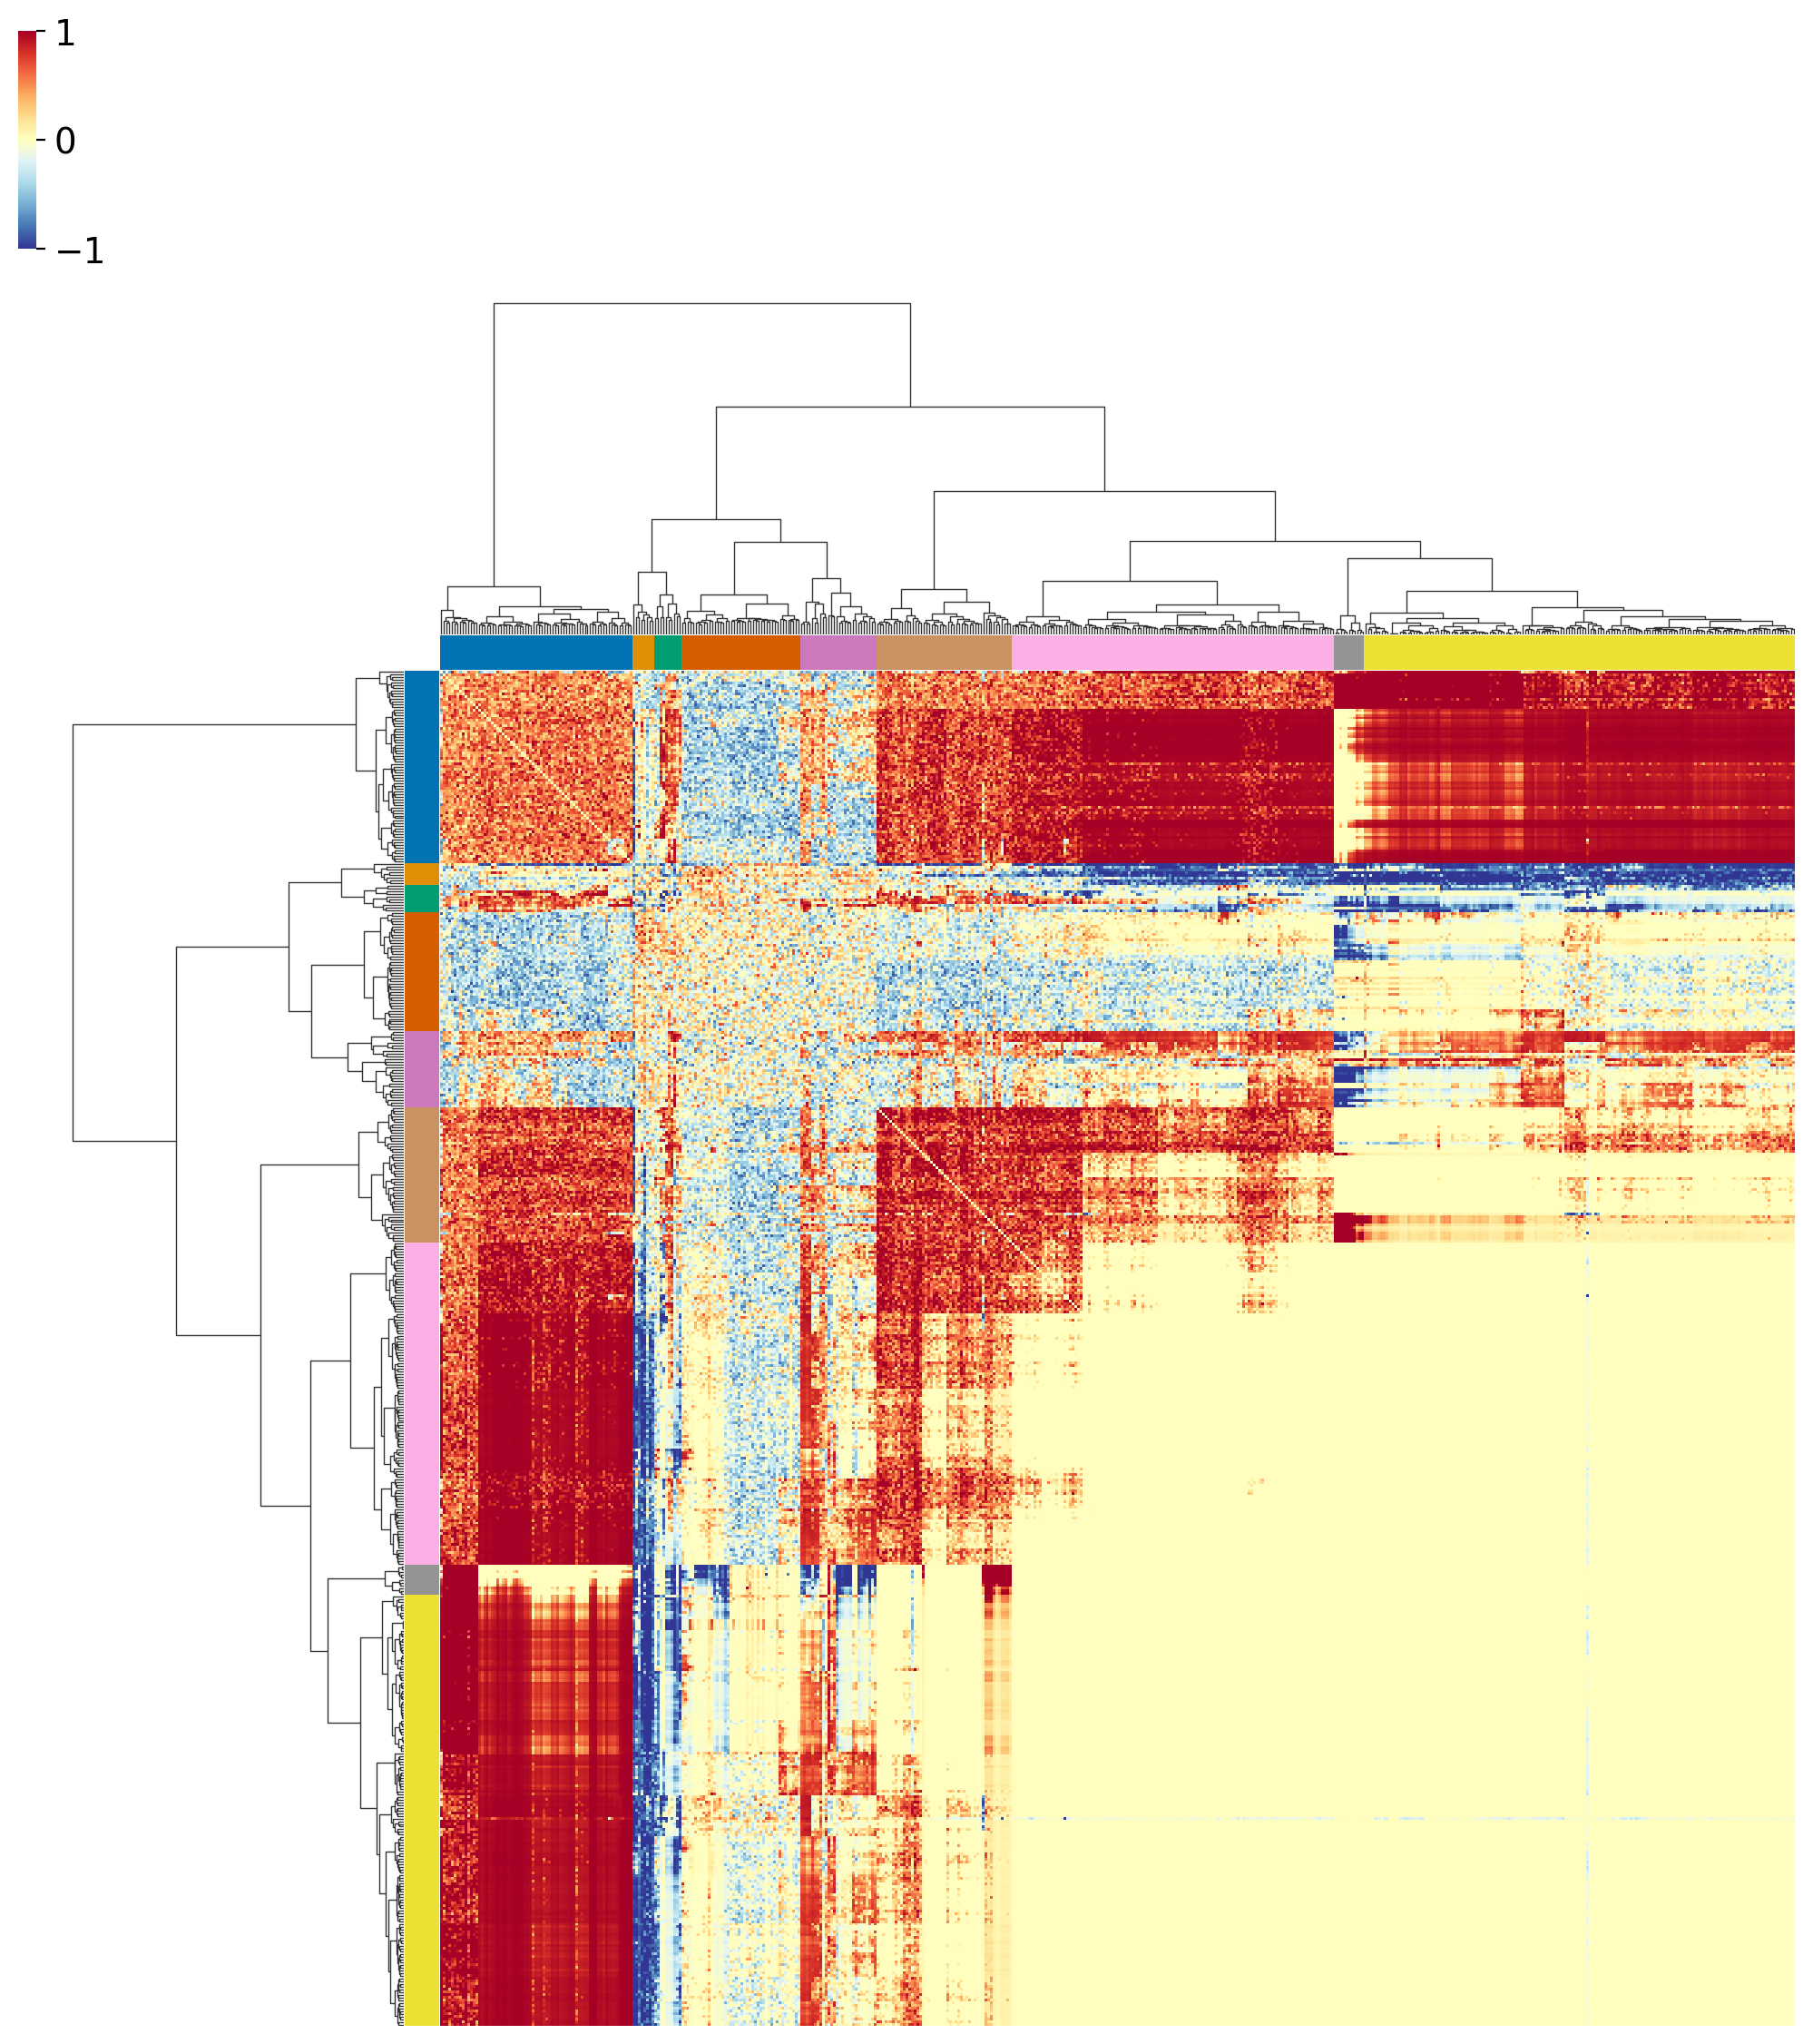

In [74]:
# show the differences
colors = clusters.map(c2c)
g = sns.clustermap(g2g_diff, vmin=-1, vmax=1, cmap='RdYlBu_r',
                   method='ward', cbar_pos=(0, 1, .01, .12), 
                   row_linkage=Z, col_linkage=Z, colors_ratio=(.02),
                   row_colors=colors, col_colors=colors,
                   xticklabels=0, yticklabels=0)
g.ax_heatmap.grid(False); g.ax_cbar.grid(False)
g.ax_col_colors.grid(False); g.ax_col_colors.set_yticks([])
g.ax_row_colors.grid(False); g.ax_row_colors.set_xticks([])

In [75]:
# assemble the non-symmetric non-identical interactions
datas = []
for cluster in clusters.unique():
    idxs = clusters.index[clusters == cluster]
    # get non-identical
    values = g2g_diff.loc[idxs, idxs].values
    flat = []
    for idx in range(values.shape[1]-1):
        flat.extend(values[idx, idx+1:].tolist())
    data = pd.DataFrame(flat, columns=['value'])
    data['cluster'] = cluster
    datas.append(data)
data = pd.concat(datas, axis=0)

/loc/scratch/7949135/ipykernel_1792/769348346.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
/loc/scratch/7949135/ipykernel_1792/769348346.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
/loc/scratch/7949135/ipykernel_1792/769348346.py:3: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'k'}` instead.

  sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
/loc/scratch/7949135/ipykernel_1792/769348346.py:3: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass

KW p=0.000e+00


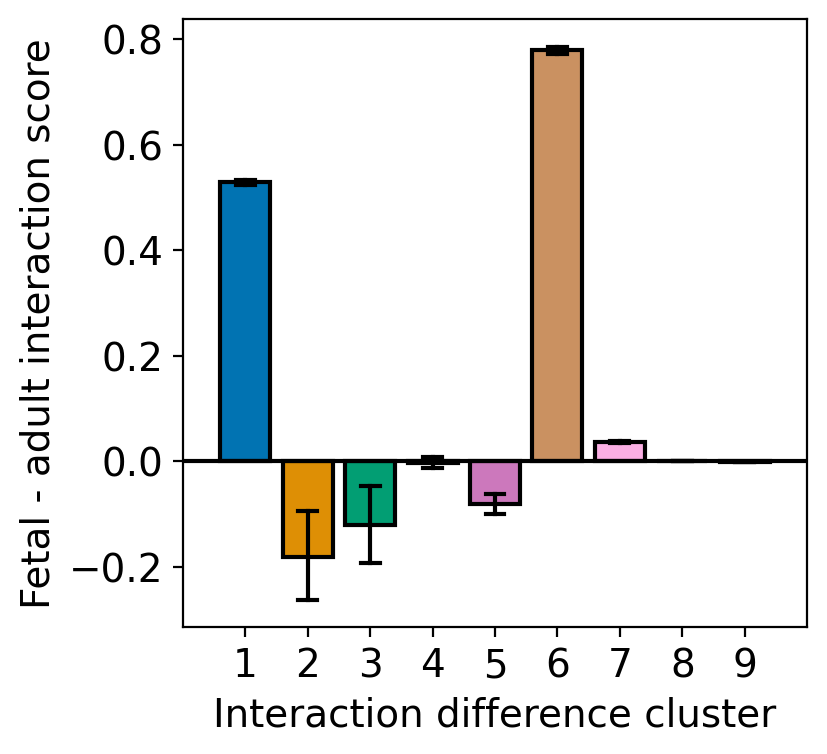

In [76]:
# identify differences with KW
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
sns.barplot(x='cluster', y='value', data=data, palette=palette, edgecolor='k', linewidth=1.5,
            ci=68, errwidth=1.5, capsize=0.3, errcolor='k', saturation=1)
ax.plot([-1, t], [0]*2, color='k'); ax.set_xlim(-1, t)
ax.set(xlabel='Interaction difference cluster', ylabel='Fetal - adult interaction score')
print('KW p=%.3e' % ss.kruskal(*[data['value'] for data in datas])[1])

In [79]:
# investigate 2, 5, 9
for x in clusters.index[clusters == 1]:
    print(x)

ITGA2B
RAB27B
XK
LAMC3
PTPRN
CTTNBP2
TUBB1
CLC
KLF1
PTPRZ1
OGN
KIAA1211
PF4V1
TTR
NECAB1
NFE2
IL17B
TNFRSF19
FOXP2
PRRG3
HBZ
CHRM3
BEX1
NR5A1
FRAS1
PKLR
AHSG
ST8SIA6
LRRC4C
FREM2
DPYSL4
GABRA2
SPOCK1
NCAM2
APOA2
TRIM58
SPTA1
ALB
PPBP
DEFA4
CLEC1B
EPB42
GP9
GYPA
SGCD
AZU1
PHOSPHO1
GPBAR1
CTNNA3
GKN2
DLK1
RHD
ESPN
RHCE
PRTN3
ELANE
LINC00632
MPIG6B
HBM
COL6A6
HBE1
HBD
AC104389.5
LILRA6
AC023154.1
MTRNR2L8
MMP2-AS1
NOTCH2NLA
DACH1
GPIHBP1
EXOC3L2


In [78]:
# investigate 2, 5, 9
for x in clusters.index[clusters == 2]:
    print(x)

CXCL11
CYP4F11
BEX5
IGLV3-1
IGHE
IGHA1
AC022182.2
MMP12


In [77]:
# investigate 2, 5, 9
for x in clusters.index[clusters == 5]:
    print(x)

GPRC5A
DDTL
KLC3
SLPI
KIR2DL1
OMG
GAD1
KLK10
SPOCD1
KRT7
CAPN11
RBP4
ACTA1
FRRS1
CD1B
HHIP
KLK11
BNC1
KRT19
SERF1A
PRIMA1
LRRN4CL
SLC28A3
INHBA-AS1
LINC00570
UPK3B
ALG1L2
AC010478.1


In [80]:
# investigate 2, 5, 9
for x in clusters.index[clusters == 9]:
    print(x)

PDK4
E2F2
JARID2
CD4
DCN
CEP68
LTF
AKAP11
EHD2
H6PD
SYNE2
TAB2
HIPK2
TIE1
PDK3
KCNAB2
PRKACA
TFRC
NOTCH3
WDR62
KIFAP3
CTTN
SIGLEC1
BRPF3
CTSG
TRIP11
PLTP
NDRG3
JAG1
USP11
FLT1
BMF
PYCR3
CASP2
PCOLCE
CLDN15
CCSER2
ACTA2
CPD
CCL8
COL1A1
HTATIP2
SC5D
CARS
VWF
PPFIBP1
FOXM1
MGP
C12orf49
C7
SPARC
CPEB4
EFEMP1
FN1
IGFBP5
EDEM3
GBP1
SLC2A1
CENPF
KLF9
IFIT3
CAAP1
PEX6
ATXN1
MT2A
IFI6
APOL3
RAB2B
XPO7
OLFM1
TOP2A
DNAJB1
UBE2G1
VPS13B
NTS
EMP1
ADAM19
KIAA0513
SLCO2B1
CXCL9
POC1B
LUM
ANKRD52
SNX27
CBR4
SLC18B1
ADIRF
ESAM
TAGLN
NEK7
RAD17
MSI2
THY1
ROBO4
FLCN
BAG4
TBC1D31
MX1
NACC1
CXCL16
S100A9
HELQ
NUAK2
SPRY1
PRIMPOL
ERAP2
COL1A2
ABCA1
DYNLT3
BTNL9
GPRC5B
ZNF641
TRAPPC9
COL3A1
CXCL10
CHD3
GIMAP8
CHST11
BCL2L1
SYNPO
CNP
CMKLR1
WSB2
MTHFR
ZBTB33
JUN
ADO
COL18A1
TENT5C
PRR14L
SMTN
FAM43A
METTL7A
TRIM69
RNPC3
PLCD1
COL4A1
ZC3H6
ACADSB
ARHGEF12
HIST1H4C
MAP3K5
PLCG2
GRK5
DCAF12
CIPC
SOX18
COL15A1
FTX
C12orf75
B3GALT4
AQP1
CTSO
HMBS
MRC1
PECAM1
AC067852.2
ARHGAP23
CCL4L2


/loc/scratch/7949135/ipykernel_26284/71933189.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Reds')


Text(0.5, 1.0, 'Interaction difference cluster 1')

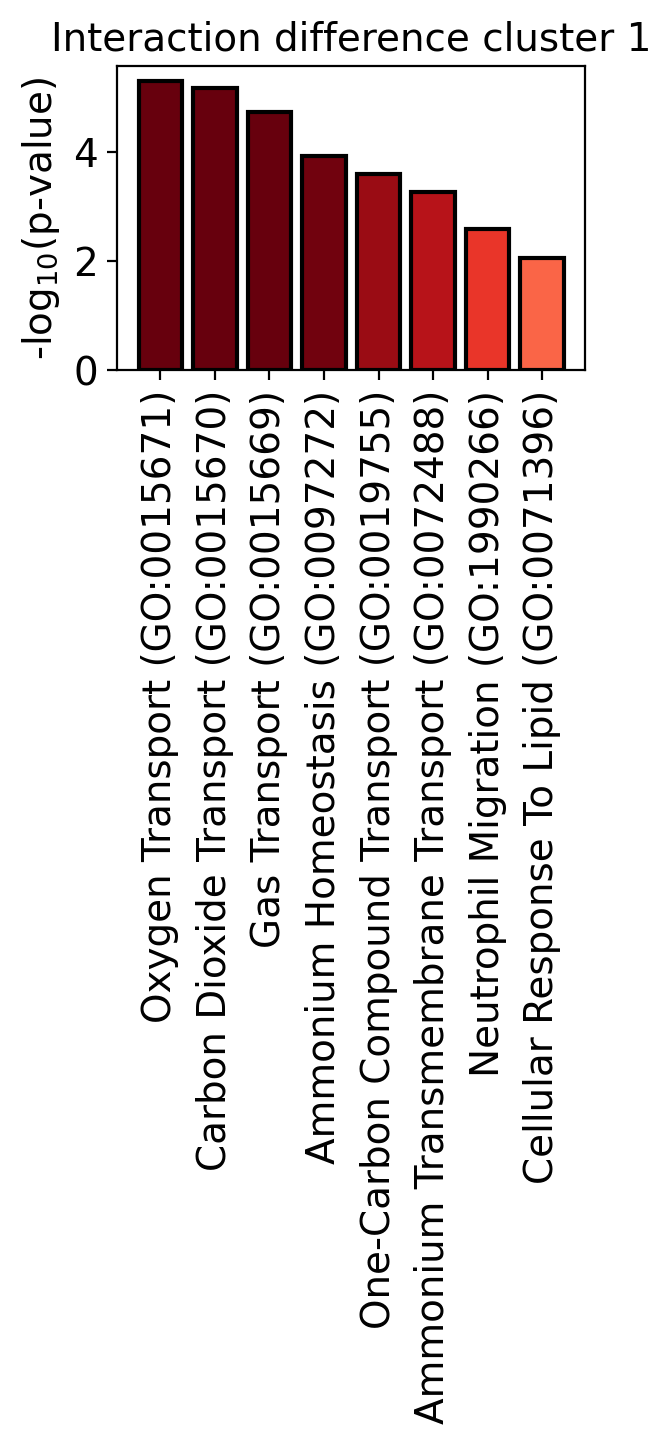

In [9]:
from matplotlib.cm import get_cmap
from matplotlib.colors import to_hex
# read in the enrichments (for non-enrichments)
pathways = '''Oxygen Transport (GO:0015671)
Carbon Dioxide Transport (GO:0015670)
Gas Transport (GO:0015669)
Ammonium Homeostasis (GO:0097272)
One-Carbon Compound Transport (GO:0019755)
Ammonium Transmembrane Transport (GO:0072488)
Neutrophil Migration (GO:1990266)
Cellular Response To Lipid (GO:0071396)'''.split('\n')
pvals = [float(x) for x in '''5.05E-06
6.93E-06
1.89E-05
1.23E-04
2.59E-04
5.49E-04
0.002598479
0.008808079'''.split('\n')]

# retrieve the colors
ys = -np.log10(pvals)
colors = [y/4 for y in ys]
cmap = get_cmap('Reds')
colors = [to_hex(cmap(c)) for c in colors]
# plot the colored bars
fig, ax = plt.subplots(figsize=[3, 2]); ax.grid(False)
ax.bar(pathways, ys, edgecolor='k', linewidth=1.5, color=colors)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('-log$_{10}$(p-value)')
ax.set_title('Interaction difference cluster 1')

/loc/scratch/7949135/ipykernel_26284/1524050370.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Reds')


Text(0.5, 1.0, 'Interaction difference cluster 2')

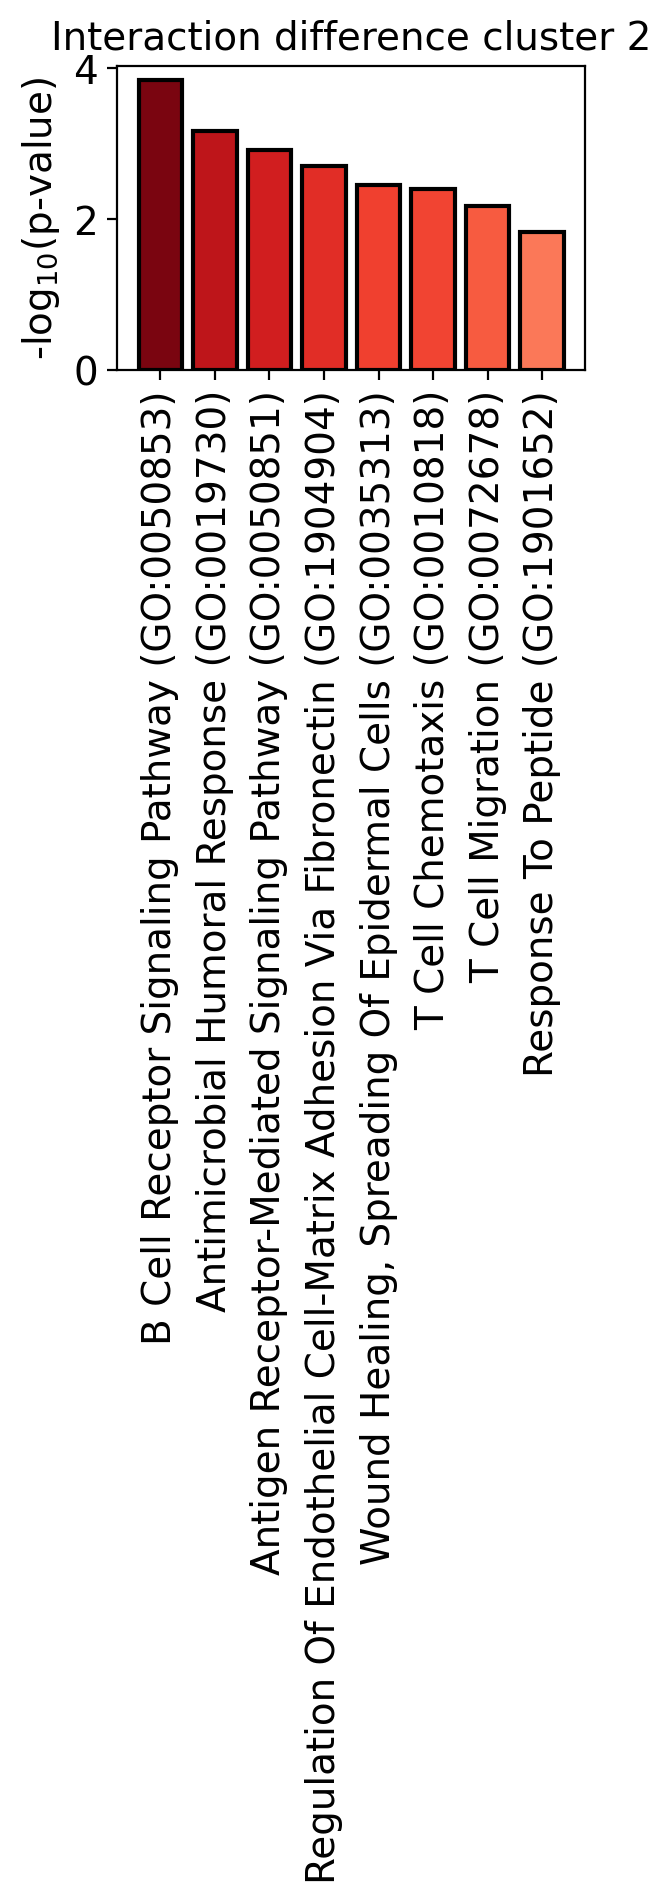

In [10]:
# read in the enrichments (for non-enrichments)
pathways = '''B Cell Receptor Signaling Pathway (GO:0050853)
Antimicrobial Humoral Response (GO:0019730)
Antigen Receptor-Mediated Signaling Pathway (GO:0050851)
Regulation Of Endothelial Cell-Matrix Adhesion Via Fibronectin (GO:1904904)
Wound Healing, Spreading Of Epidermal Cells (GO:0035313)
T Cell Chemotaxis (GO:0010818)
T Cell Migration (GO:0072678)
Response To Peptide (GO:1901652)'''.split('\n')
pvals = [float(x) for x in '''1.44E-04
6.80E-04
0.001215037
0.001998563
0.003594909
0.003993646
0.006780906
0.015101799'''.split('\n')]

# retrieve the colors
ys = -np.log10(pvals)
colors = [y/4 for y in ys]
cmap = get_cmap('Reds')
colors = [to_hex(cmap(c)) for c in colors]
# plot the colored bars
fig, ax = plt.subplots(figsize=[3, 2]); ax.grid(False)
ax.bar(pathways, ys, edgecolor='k', linewidth=1.5, color=colors)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('-log$_{10}$(p-value)')
ax.set_title('Interaction difference cluster 2')

/loc/scratch/7949135/ipykernel_26284/98617427.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Reds')


Text(0.5, 1.0, 'Interaction difference cluster 5')

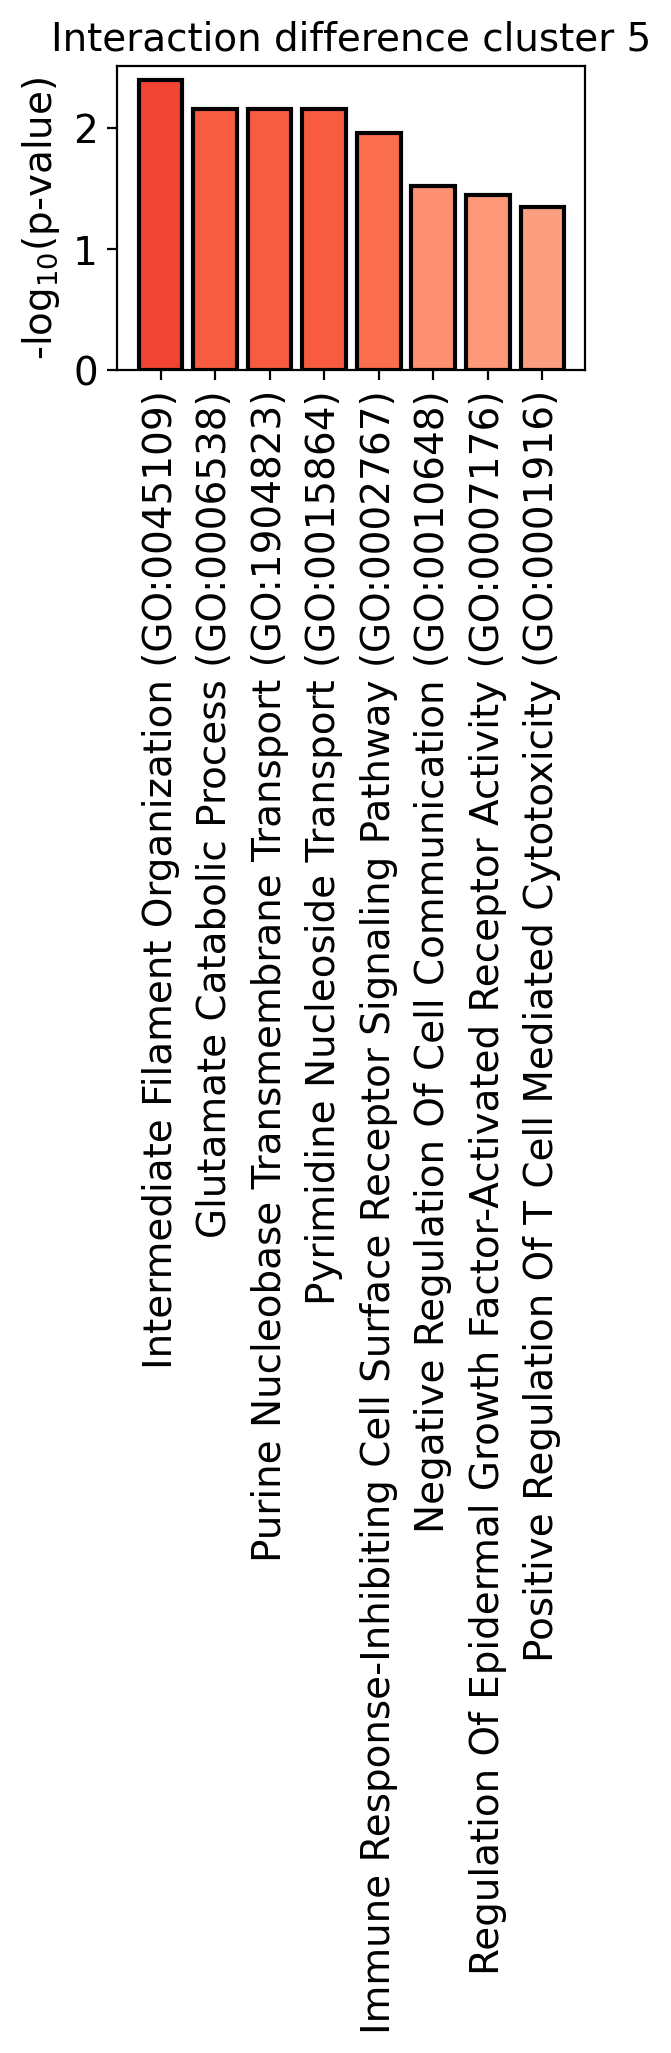

In [11]:
# read in the enrichments (for non-enrichments)
pathways = '''Intermediate Filament Organization (GO:0045109)
Glutamate Catabolic Process (GO:0006538)
Purine Nucleobase Transmembrane Transport (GO:1904823)
Pyrimidine Nucleoside Transport (GO:0015864)
Immune Response-Inhibiting Cell Surface Receptor Signaling Pathway (GO:0002767)
Negative Regulation Of Cell Communication (GO:0010648)
Regulation Of Epidermal Growth Factor-Activated Receptor Activity (GO:0007176)
Positive Regulation Of T Cell Mediated Cytotoxicity (GO:0001916)'''.split('\n')
pvals = [float(x) for x in '''0.00406662
0.006981041
0.006981041
0.006981041
0.011147105
0.030366962
0.035791859
0.045215085'''.split('\n')]

# retrieve the colors
ys = -np.log10(pvals)
colors = [y/4 for y in ys]
cmap = get_cmap('Reds')
colors = [to_hex(cmap(c)) for c in colors]
# plot the colored bars
fig, ax = plt.subplots(figsize=[3, 2]); ax.grid(False)
ax.bar(pathways, ys, edgecolor='k', linewidth=1.5, color=colors)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('-log$_{10}$(p-value)')
ax.set_title('Interaction difference cluster 5')

/loc/scratch/7949135/ipykernel_26284/3567964154.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Reds')


Text(0.5, 1.0, 'Interaction difference cluster 9')

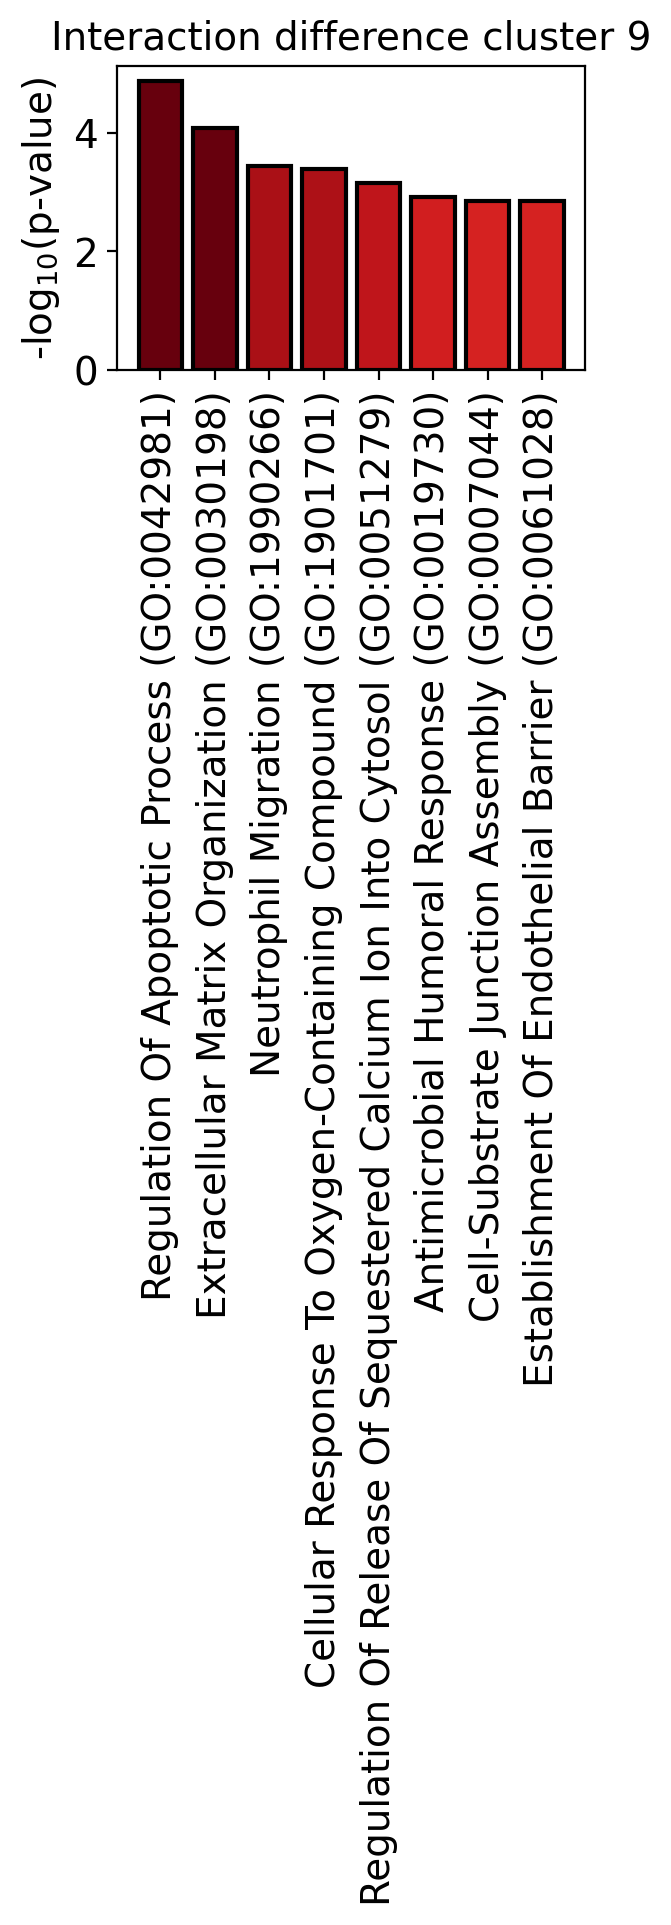

In [13]:
# read in the enrichments (for non-enrichments)
pathways = '''Regulation Of Apoptotic Process (GO:0042981)
Extracellular Matrix Organization (GO:0030198)
Neutrophil Migration (GO:1990266)
Cellular Response To Oxygen-Containing Compound (GO:1901701)
Regulation Of Release Of Sequestered Calcium Ion Into Cytosol (GO:0051279)
Antimicrobial Humoral Response (GO:0019730)
Cell-Substrate Junction Assembly (GO:0007044)
Establishment Of Endothelial Barrier (GO:0061028)'''.split('\n')
pvals = [float(x) for x in '''1.33E-05
8.41E-05
3.71E-04
4.16E-04
7.19E-04
0.001222974
0.001395807
0.001395807'''.split('\n')]

# retrieve the colors
ys = -np.log10(pvals)
colors = [y/4 for y in ys]
cmap = get_cmap('Reds')
colors = [to_hex(cmap(c)) for c in colors]
# plot the colored bars
fig, ax = plt.subplots(figsize=[3, 2]); ax.grid(False)
ax.bar(pathways, ys, edgecolor='k', linewidth=1.5, color=colors)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('-log$_{10}$(p-value)')
ax.set_title('Interaction difference cluster 9')